# The imports

In [24]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load the Resutls File

In [25]:
file_name = "general_results.pkl"

In [26]:
dictionaries = pickle.load(open(file_name, "rb"))

In [27]:
always_include = [
    "PlugInRule",
    "PlugInRuleAUC"
]

In [28]:
coverage_tolerance = 0.02
min_target_coverage = 0.6

# Save raw baseline rows BEFORE filtering, baselines must always be available for plots
raw_baselines = {}
for k0 in dictionaries:
    raw_baselines[k0] = {}
    for k2 in dictionaries[k0][next(k for k in dictionaries[k0] if "coverage" not in k)]:
        raw_baselines[k0][k2] = {}
        for k1 in dictionaries[k0]:
            if "coverage" in k1:
                continue
            df = dictionaries[k0][k1][k2]
            raw_baselines[k0][k2][k1] = df.loc[[b for b in always_include if b in df.index]]

# First pass: collect all violations per method
violation_counts = {}
for k0 in dictionaries:
    for k2 in dictionaries[k0][list(dictionaries[k0].keys())[0]]:
        ref_metric = next(k for k in dictionaries[k0] if "coverage" not in k)
        perf_ref = dictionaries[k0][ref_metric][k2]
        cov_df   = dictionaries[k0]["calibration_coverage"][k2]
        for col in perf_ref.columns:
            over_rejecting = cov_df[col] < (col - coverage_tolerance)
            for method in over_rejecting.index[over_rejecting]:
                violation_counts[method] = violation_counts.get(method, 0) + 1

print("Over-rejection summary (method, #violations):")
for method, count in sorted(violation_counts.items(), key=lambda x: -x[1]):
    print(f"  {count:4d}  {method}")

# Second pass: apply the over-rejection filter and drop columns below min_target_coverage
for k0 in dictionaries:
    for k1 in dictionaries[k0]:
        if "coverage" in k1:
            continue
        for k2 in dictionaries[k0][k1]:
            perf_df = dictionaries[k0][k1][k2].copy()
            cov_df  = dictionaries[k0]["calibration_coverage"][k2]
            for col in perf_df.columns:
                over_rejecting = cov_df[col] < (col - coverage_tolerance)
                perf_df.loc[over_rejecting, col] = np.nan
            perf_df = perf_df.dropna(how='any')
            perf_df = perf_df.loc[:, [col for col in perf_df.columns if col >= min_target_coverage]]
            dictionaries[k0][k1][k2] = perf_df

print(f"\nCoverage proximity filter applied (tolerance={coverage_tolerance:.0%})")
print(f"Columns with target coverage < {min_target_coverage:.0%} dropped")

Over-rejection summary (method, #violations):
   254  growingspheres_CFDistRejector_spearman_min_gamma
   241  ils<latent_CFDistRejector_kendall_min_gamma
   239  ils<latent_CFDistRejector_spearman_min_gamma
   225  growingspheres_CFDistRejector_kendall_min_gamma
   198  growingspheres_CFDistRejector_correlation_min_gamma
   193  growingspheres_CFDistRejector_centered_cosine_max_gamma
   193  growingspheres_CFDistRejector_centered_cosine_mean_gamma
   188  growingspheres_CFDistRejector_kendall_mean_gamma
   182  growingspheres_CFDistRejector_centered_l2_max_gamma
   181  growingspheres_CFDistRejector_correlation_mean_gamma
   179  growingspheres_CFDistRejector_centered_l2_min_gamma
   179  growingspheres_CFDistRejector_centered_l2_mean_gamma
   175  growingspheres_CFDistRejector_kendall_max_gamma
   162  growingspheres_CFDistRejector_spearman_max_gamma
   159  growingspheres_CFDistRejector_correlation_max_gamma
   158  growingspheres_CFDistRejector_centered_cosine_min_gamma
   158  gro

In [29]:
# Summary: how many (dataset, model) combinations had each method fully removed
# (i.e., dropped because it over-rejected at every coverage level)
# This re-reads the current dictionaries AFTER filtering to find what's missing
# compared to the raw method list from the first metric/model/dataset seen.

import warnings
# Collect all method names that appear in ANY combo
all_methods_seen = set()
all_methods_per_combo = {}
for d in dictionaries:
    for k1 in dictionaries[d]:
        if "coverage" in k1:
            continue
        for m in dictionaries[d][k1]:
            all_methods_seen.update(dictionaries[d][k1][m].index)
            all_methods_per_combo[(d, k1, m)] = set(dictionaries[d][k1][m].index)

print(f"Total unique methods still present after filtering: {len(all_methods_seen)}")
print(f"Total (dataset, metric, model) combos: {len(all_methods_per_combo)}")


Total unique methods still present after filtering: 286
Total (dataset, metric, model) combos: 48


In [30]:
""" this module contains the function to compute the statistics of numpy matrix"""

import scikit_posthocs as sp
import scipy.stats as ss
import pandas as pd
import matplotlib.pyplot as plt
from decimal import Decimal
import numpy as np
import seaborn as sns
from selective_classifiers import fancy_names
def remap_names(ranking_df,colors_dict=None):
    '''this function is used to remap the names of the methods to more meaningful names. It is used to plot the critical difference diagram.
    '''
    # create colors_dict as a dictionary that maps the color based on the content of the content of ranking_df
    res_colors = {fancy_names(k):"black" for k,v in ranking_df.items()}
    # rankin_df is a dataframe that has as many columns called as the methods 
    # to remap the names of the methods we use the res_d dictionary
    ranking_df.columns = [fancy_names(col) for col in ranking_df.columns]
    print(res_colors,"res_colors")
    print(ranking_df.columns,"columns of the ranking_df")
    return ranking_df,res_colors


In [31]:
cd_diagram_save_folder = "SC-CE-paper/cd_diagrams"

In [68]:
fancy_metric = {"rejection_quality_dict": "Rejection Quality",
                "non_rejected_accuracy": "Non-Rejected Accuracy",
                "classification_quality_dict": "Classification Quality",
                "coverage": "Coverage"}
fancy_dataset = {"german_credit": "German",
                 "adult48k": "Adult",
                 "toy_dataset": "Two-Moons",
                 "breast_cancer": "Wisconsin"}
from selective_classifiers import fancy_names as fancy_model


In [33]:
def create_df_and_check2(methods_names,
                        values,
                        title="",
                        title_size=18,
                        exp="",
                        metrica='',
                        dt_name='dt_name',
                        vmin=0,
                        vmax=0.4,
                        hmargin=0.1,
                        vertica_image_size=5,
                        invert=False,
                        colors_dict=None,
                        minmax = False,
                        meanstd = False):
    '''Creates CD diagram with statistical testing'''
    
    # Create dataframe
    df = pd.DataFrame(values, columns=methods_names)
    
    # Compute ranks
    # The 'invert' parameter controls ranking order:
    # - invert=False: ascending=False → rank 1 for highest values (for metrics where HIGHER is BETTER, e.g., accuracy, rejection_quality_dict)
    # - invert=True: ascending=True → rank 1 for lowest values (for metrics where LOWER is BETTER, e.g., error rate)
    # NOTE: rejection_quality_dict is HIGHER-IS-BETTER (a quality metric), so should use invert=False
    is_minimized = invert  # True if lower is better, False if higher is better
    print(f"Ranking: invert={invert} → ascending={is_minimized}")
    print(f"  Metric: {metrica}")
    print(f"  Rank 1 goes to: {'lowest value' if is_minimized else 'highest value'}")
    ranks = df.rank(axis=1, ascending=is_minimized)
    # Calculate mean values for each method (before name remapping)
    mean_values = df.mean(axis=0)
    std_values = df.std(axis=0)
    min_values = df.min(axis=0)
    max_values = df.max(axis=0)
    # print the rank/values of the first 5 rows to check
    
    
    # Validate shape
    assert ranks.shape[1] == len(methods_names), \
        "Ranks have different number of columns than method names"
    
    # Friedman test
    _, p_friedman = ss.friedmanchisquare(*values)
    
    # Nemenyi post-hoc test
    cd = sp.posthoc_nemenyi_friedman(ranks)
    
    # Check if Friedman test is significant
    if p_friedman < 0.05 and len(values) >= 2:
        fig, ax = plt.subplots(1, 1, figsize=(10, vertica_image_size))
        
        # Remap names and get colors
        ranks_res, colors_res = remap_names(ranking_df=ranks, colors_dict=colors_dict)
        
        
        
        # Create mapping from fancy names back to original names
        name_mapping = {fancy_names(orig): orig for orig in methods_names}
        
        # Prepare CD matrix for plotting
        cd_plot = cd.copy()
        cd_plot.columns = [fancy_names(col) for col in cd.columns]
        cd_plot.index = cd_plot.columns
        
        # Check if there are any significant pairwise differences
        cd_no_diag = cd.values.copy()
        np.fill_diagonal(cd_no_diag, 1.0)
        has_significant = (cd_no_diag < 0.05).any()
        
        if has_significant:
            print("Plotting CD diagram")
            mean_ranks = ranks_res.T.mean(axis=1)
            #print(mean_ranks)
            #print("---")
            
            label_props = {"fontsize": title_size - 1}
            black_colors = {k: "black" for k in colors_res.keys()}
            ax.set_xlim(1, len(methods_names))
            # checking shapes
            
            # print(mean_ranks.shape)
            # print(mean_ranks.keys())
            # print(len(list(black_colors.keys())))
            # print("\n".join([f"{jj}: {k}" for jj,k in enumerate(list(black_colors.keys()))]))
            # print("\n".join([f"{jj}: {k}" for jj,k in enumerate(list(colors_res.keys()))]))
            # input()

            # Plot critical difference diagram
            res_dict = sp.critical_difference_diagram(
                mean_ranks,
                cd_plot,
                label_props=label_props,
                color_palette=black_colors,
                ax=ax,
                text_h_margin=hmargin
            )
            #res_dict = {
            #    "markers": markers,
            #    "elbows": elbows,
            #    "labels": labels,
            #    "crossbars": crossbars,
            #}
            # Add mean values as text annotations next to method names
            # Get the y-positions of the method labels from the CD diagram
            for text_obj in res_dict['labels']:
                # check if the rank is at right or left
                rank_str_is_on_right = text_obj.get_text().endswith(")")  # Check if the label already has mean value
                if rank_str_is_on_right:
                    method_name = " ".join(text_obj.get_text().split()[:-1])  # Get the method name without mean value
                    rank_s = text_obj.get_text().split()[-1]  # Get the rank part
                else:
                    method_name = " ".join(text_obj.get_text().split()[1:])  # Get the method name without rank
                    rank_s = text_obj.get_text().split()[0]  # Get the rank part

                
                original_name = name_mapping.get(method_name, method_name)
                mean_value = mean_values[original_name]
                # Format mean value with 2 decimal places
                mean_value_str = f"{mean_value:.2f}"
                std_value_str = f"{std_values[original_name]:.2f}"
                minmax_str = f"({min_values[original_name]:.2f} - {max_values[original_name]:.2f})"
                # Append mean value and standard deviation to the label
                if minmax:
                    std_value_str = std_value_str + f" {minmax_str}"
                if meanstd:
                    new_l = f"{rank_s} {method_name} ({mean_value_str} ± {std_value_str})" if not rank_str_is_on_right else f"{method_name} {rank_s} ({mean_value_str} ± {std_value_str})"
                else:
                    new_l = f"{rank_s} {method_name}" if not rank_str_is_on_right else f"{method_name} {rank_s}"
                text_obj.set_text(new_l)
            
            # Find the minimum significant p-value for the title
            min_p = cd_no_diag[cd_no_diag < 0.05].min()
            p_str = f"{min_p:.3E}"
            title += f"\nFriedman p={p_friedman:.3E}, min pairwise p={p_str}"
            
        else:
            ax.text(0.5, 0.5, "No significant pairwise differences", 
                   fontsize=20, ha='center', va='center')
            ax.axis('off')
            title += f"\nFriedman p={p_friedman:.3E} (no sig. pairwise diffs)"
        
    else:
        fig, ax = plt.subplots(1, 1, figsize=(10, vertica_image_size))
        
        if len(values) < 2:
            msg = "Need at least 2 domains for statistical testing"
        else:
            msg = f"Friedman test not significant\n(p={p_friedman:.3f})"
        
        ax.text(0.5, 0.5, msg, fontsize=20, ha='center', va='center')
        ax.axis('off')
        title += f"\nFriedman p={p_friedman:.3E}"
    
    plt.suptitle(title, fontsize=title_size)
    plt.tight_layout()
        
    return fig, ax

In [34]:
for k0 in dictionaries.keys():
    print(f"\nDataset: {k0}")
    for k1 in dictionaries[k0].keys():

        print(f"  Metric:{k1}:")
        for k2 in dictionaries[k0][k1].keys():
            print(f"    Model: {k2}")
            for t in dictionaries[k0][k1][k2].columns:
                methods_list = dictionaries[k0][k1][k2].index.tolist()
                print(f"      Target coverage: {t}, {len(methods_list)} methods: {methods_list[:5]} ...")
                if t <= 0.95:
                    print("      ...\n")
                    break
        print("\n   ---  same for other metrics")
        break
    print("\n,,, same for other datasets")
    break
                


Dataset: toy_dataset
  Metric:rejection_quality_dict:
    Model: mlp
      Target coverage: 0.98, 220 methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_mean'] ...
      Target coverage: 0.96, 220 methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_mean'] ...
      Target coverage: 0.95, 220 methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_mean'] ...
      ...

    Model: lip_mlp
      Target coverage: 0.98, 206 methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_inf_min', 'growingspheres_CFDistRejector_inf_max', 'growingspheres_CFDistRejector_inf_mean'] ...
      Target coverage: 0.96, 206 methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CF

In [35]:

# incldue metrics 
metrics_to_include = [
"l2",
"or_cosine",
"canberra",
"jaccard",
"centerd_l2",
"plugin"
]
metrics_to_include = sorted(metrics_to_include)
metrics_to_include

['canberra', 'centerd_l2', 'jaccard', 'l2', 'or_cosine', 'plugin']

In [36]:
for dataset, metrics_dict in dictionaries.items():
    for metric, models_dict in metrics_dict.items():
        for model, coverages_df in models_dict.items():
            # Find the methods to keep (index filtering)
            methods_to_keep = [m for m in coverages_df.index if any(m2i in m.lower() for m2i in metrics_to_include)]
            # Filter the DataFrame to only those methods
            models_dict[model] = coverages_df.loc[methods_to_keep]

In [37]:
for k0 in dictionaries.keys():
    print(f"\nDataset: {k0}")
    for k1 in dictionaries[k0].keys():

        print(f"  Metric:{k1}:")
        for k2 in dictionaries[k0][k1].keys():
            print(f"    Model: {k2}")
            for t in dictionaries[k0][k1][k2].columns:
                print(f"      Target coverage: {t}, methods: {dictionaries[k0][k1][k2].index.tolist()[:5]} ...")
                if t <= 0.95:
                    print("      ...\n")
                    break
        print("\n   ---  same for other metrics")
        break
    print("\n,,, same for other datasets")
    break
                
                


Dataset: toy_dataset
  Metric:rejection_quality_dict:
    Model: mlp
      Target coverage: 0.98, methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_mean'] ...
      Target coverage: 0.96, methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_mean'] ...
      Target coverage: 0.95, methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_mean'] ...
      ...

    Model: lip_mlp
      Target coverage: 0.98, methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_mean'] ...
      Target coverage: 0.96, methods: ['PlugInRule', 'PlugInRuleAUC', 'growingspheres_CFDistRejector_l2_min', 'growingsp

In [38]:
metric = "non_rejected_accuracy"
top_n  = 10
always_include = ["PlugInRule", "PlugInRuleAUC"]
exclude_gamma  = True   # set False to include _gamma variants in ranking

all_datasets = list(dictionaries.keys())
all_models   = list(dictionaries[all_datasets[0]][metric].keys())


def get_top_methods(datasets, models, top_n):
    scores = {}
    for d in datasets:
        for m in models:
            df = dictionaries[d][metric][m]
            for method in df.index:
                val = df.loc[method].mean()
                if not np.isnan(val):
                    scores.setdefault(method, []).append(val)
    method_means = {k: np.mean(v) for k, v in scores.items()}
    ranked = [m for m in sorted(method_means, key=method_means.get, reverse=True)
              if m not in always_include
              and (not exclude_gamma or "_gamma" not in m)][:top_n]
    for b in always_include:
        if b in method_means:
            ranked.append(b)
    return ranked     


def build_matrix(datasets, models, top_methods, require_complete_blocks=True):
    """
    require_complete_blocks=True (default):
        Only use (dataset, model) blocks where ALL top_methods are present.
        Returns a complete matrix suitable for the Friedman test.

    require_complete_blocks=False:
        Use all available blocks. For each block, rank only the methods present.
        Returns (mean_ranks dict, counts dict) instead of a matrix.
        Friedman test is not applicable, ranking is shown without significance.
    """
    if require_complete_blocks:
        blocks = []
        for d in datasets:
            for m in models:
                df = dictionaries[d][metric][m]
                if all(meth in df.index for meth in top_methods):
                    blocks.append(df.loc[top_methods].values.T)
        if not blocks:
            raise ValueError("No complete blocks found.")
        stacked = np.vstack(blocks)
        print(f"  {len(blocks)} complete blocks, {stacked.shape[0]} observations, {stacked.shape[1]} methods")
        return stacked
    else:
        rank_sum   = {m: 0.0 for m in top_methods}
        rank_count = {m: 0   for m in top_methods}
        n_blocks_used = 0
        for d in datasets:
            for m in models:
                df = dictionaries[d][metric][m]
                present = [meth for meth in top_methods if meth in df.index]
                if len(present) < 2:
                    continue
                n_blocks_used += 1
                sub = df.loc[present]
                ranked = sub.T.rank(axis=1, ascending=False)
                for meth in present:
                    rank_sum[meth]   += ranked[meth].mean()
                    rank_count[meth] += 1
        mean_ranks = {m: rank_sum[m] / rank_count[m] if rank_count[m] > 0 else np.nan
                      for m in top_methods}
        present_methods = [m for m in top_methods if not np.isnan(mean_ranks[m])]
        print(f"  {n_blocks_used} blocks used (incomplete design, no Friedman), {len(present_methods)} methods with data")
        return mean_ranks, rank_count


def run_cd(title, datasets, models, save_path, require_complete_blocks=True):
    top_methods = get_top_methods(datasets, models, top_n)
    print(f"\n{title}\n  top methods: {top_methods}")

    if require_complete_blocks:
        values = build_matrix(datasets, models, top_methods, require_complete_blocks=True)
        n_obs = values.shape[0]
        fig, ax = create_df_and_check2(top_methods, values,
                             title + f" (n={n_obs})",
                             metrica=fancy_metric[metric],
                             invert=False, 
                             vertica_image_size=3
                             # meanstd=True, minmax=True
                             )
    else:
        mean_ranks, rank_count = build_matrix(datasets, models, top_methods, require_complete_blocks=False)
        present = [m for m in top_methods if not np.isnan(mean_ranks[m])]
        mr_series = pd.Series({fancy_names(m): mean_ranks[m] for m in present}).sort_values()

        fig, ax = plt.subplots(figsize=(10, max(3, len(present) * 0.4 + 1)))
        ax.barh(mr_series.index, mr_series.values, color="steelblue")
        ax.set_xlabel("Average rank (1 = best)")
        ax.invert_xaxis()
        ax.set_title(title + " [incomplete blocks, no significance test]", fontsize=13)
        for i, m in enumerate(present):
            ax.text(mr_series[fancy_names(m)] + 0.05, i,
                    f"n_blocks={rank_count[m]}", va='center', fontsize=8)
        plt.tight_layout()

    plt.savefig(save_path, bbox_inches='tight')
    print("Saved CD diagram to:", save_path)
    #plt.show()
    #plt.close()



Top 10, Non-Rejected Accuracy, All datasets, All models
  top methods: ['growingspheres_CFDistRejector_centered_l2_mean', 'growingspheres_CFDistRejector_cosine_mean', 'ils<latent_CFDistRejector_cosine_mean', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_centered_l2_max', 'growingspheres_CFDistRejector_canberra_min', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_centered_l2_min', 'growingspheres_CFDistRejector_cosine_max', 'ils<latent_CFDistRejector_l2_min', 'PlugInRule', 'PlugInRuleAUC']
  10 complete blocks, 220 observations, 12 methods
Ranking: invert=False → ascending=False
  Metric: Non-Rejected Accuracy
  Rank 1 goes to: highest value
{'GS - centered L2$_{avg}$': 'black', 'GS - cosine$_{avg}$': 'black', 'ILS$_L$ - cosine$_{avg}$': 'black', 'GS - L2$_{max}$': 'black', 'GS - centered L2$_{max}$': 'black', 'GS - canberra$_{min}$': 'black', 'GS - L2$_{avg}$': 'black', 'GS - centered L2$_{min}$': 'black', 'GS - cosine$_{max}$': 'black

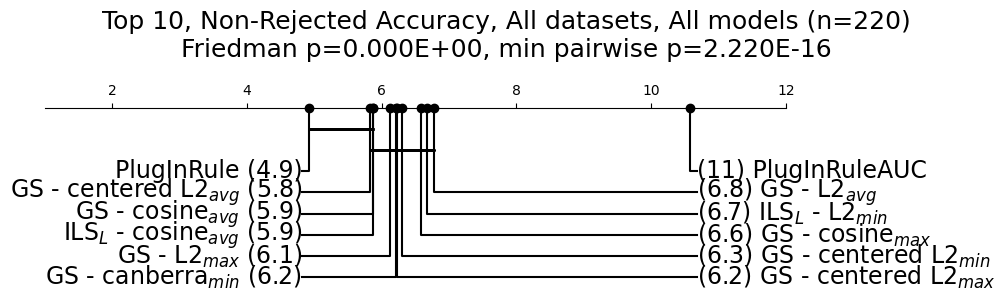

In [67]:
# 1. Aggregated
run_cd(f"Top {top_n}, {fancy_metric[metric]}, All datasets, All models",
       [d for d in all_datasets if d != 'toy_dataset'], all_models,
       f"{cd_diagram_save_folder}/cd_{metric}_aggregated.pdf")



Top 10, Non-Rejected Accuracy, Two-Moons
  top methods: ['growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_mean', 'lore_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_canberra_max', 'growingspheres_CFDistRejector_canberra_mean', 'growingspheres_CFDistRejector_canberra_min', 'growingspheres_CFDistRejector_cosine_max', 'growingspheres_CFDistRejector_cosine_mean', 'lore_CFDistRejector_canberra_min', 'PlugInRule', 'PlugInRuleAUC']
  2 complete blocks, 44 observations, 12 methods
Ranking: invert=False → ascending=False
  Metric: Non-Rejected Accuracy
  Rank 1 goes to: highest value
{'GS - L2$_{max}$': 'black', 'GS - L2$_{avg}$': 'black', 'LORE - L2$_{min}$': 'black', 'GS - L2$_{min}$': 'black', 'GS - canberra$_{max}$': 'black', 'GS - canberra$_{avg}$': 'black', 'GS - canberra$_{min}$': 'black', 'GS - cosine$_{max}$': 'black', 'GS - cosine$_{avg}$': 'black', 'LORE - canberra$_{min}$': 'black', 'PlugInRule': 'black', 'Pl

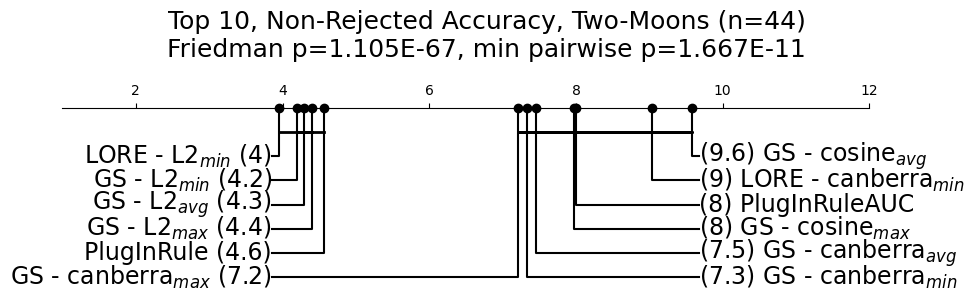

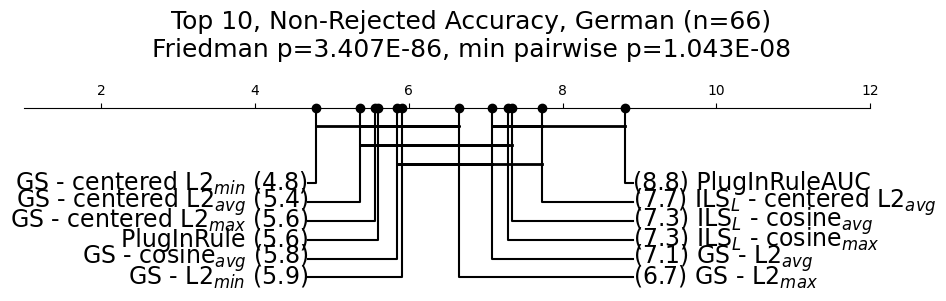

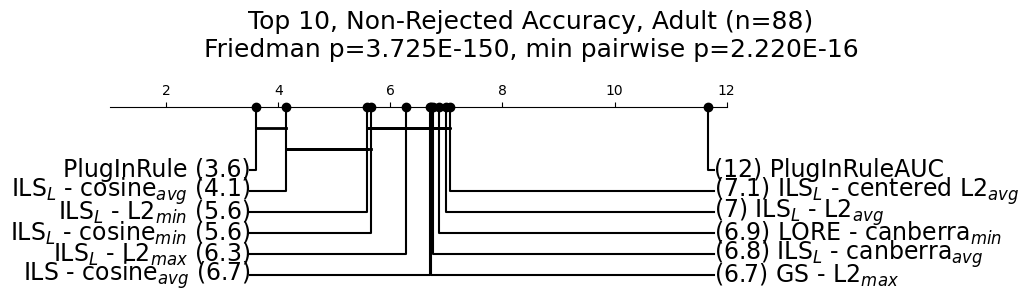

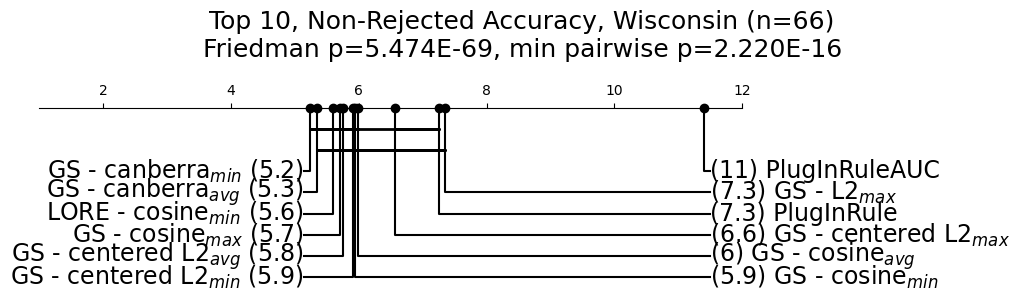

In [40]:
# 2. By dataset
for dataset in all_datasets:
    run_cd(f"Top {top_n}, {fancy_metric[metric]}, {fancy_dataset.get(dataset, dataset)}",
           [dataset], all_models,
           f"{cd_diagram_save_folder}/cd_{metric}_dataset_{dataset}.pdf")



Top 10, Non-Rejected Accuracy, mlp
  top methods: ['lore_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_max', 'growingspheres_CFDistRejector_l2_min', 'growingspheres_CFDistRejector_l2_mean', 'growingspheres_CFDistRejector_cosine_max', 'growingspheres_CFDistRejector_canberra_min', 'growingspheres_CFDistRejector_cosine_mean', 'growingspheres_CFDistRejector_canberra_mean', 'growingspheres_CFDistRejector_cosine_min', 'lore_CFDistRejector_canberra_min', 'PlugInRule', 'PlugInRuleAUC']
  4 complete blocks, 88 observations, 12 methods
Ranking: invert=False → ascending=False
  Metric: Non-Rejected Accuracy
  Rank 1 goes to: highest value
{'LORE - L2$_{min}$': 'black', 'GS - L2$_{max}$': 'black', 'GS - L2$_{min}$': 'black', 'GS - L2$_{avg}$': 'black', 'GS - cosine$_{max}$': 'black', 'GS - canberra$_{min}$': 'black', 'GS - cosine$_{avg}$': 'black', 'GS - canberra$_{avg}$': 'black', 'GS - cosine$_{min}$': 'black', 'LORE - canberra$_{min}$': 'black', 'PlugInRule': 'black', 'PlugInRuleAU

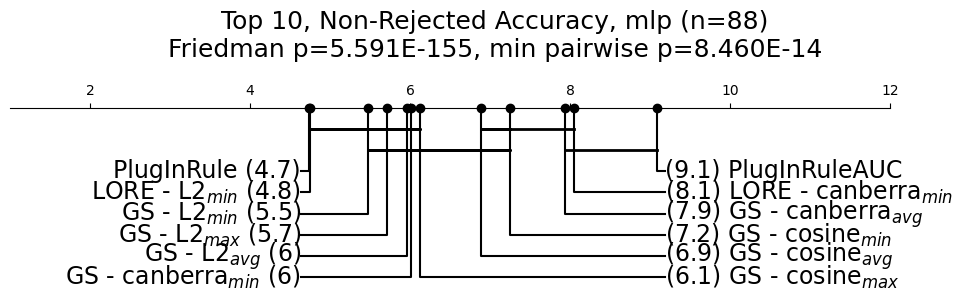

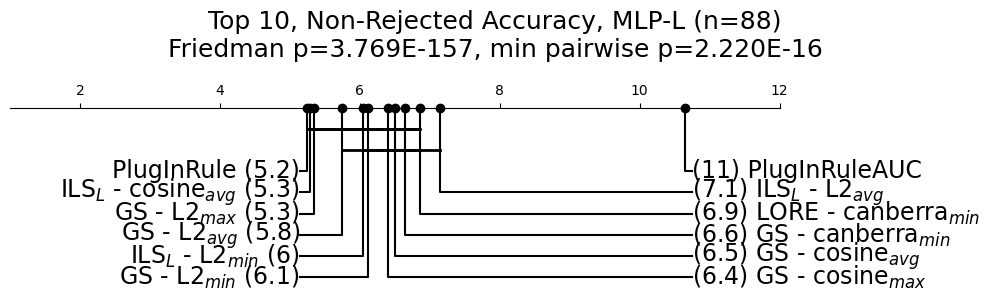

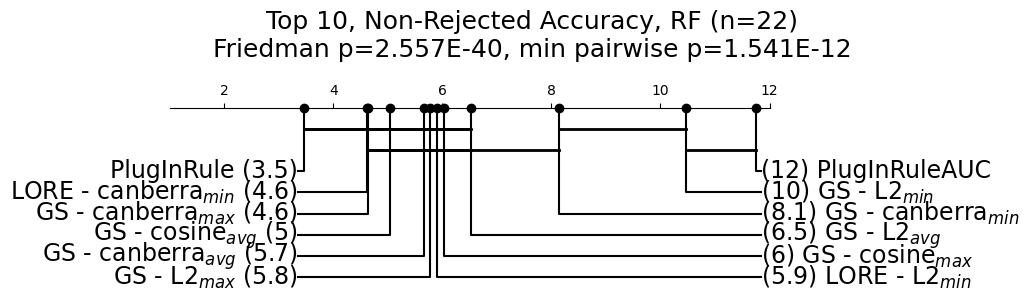

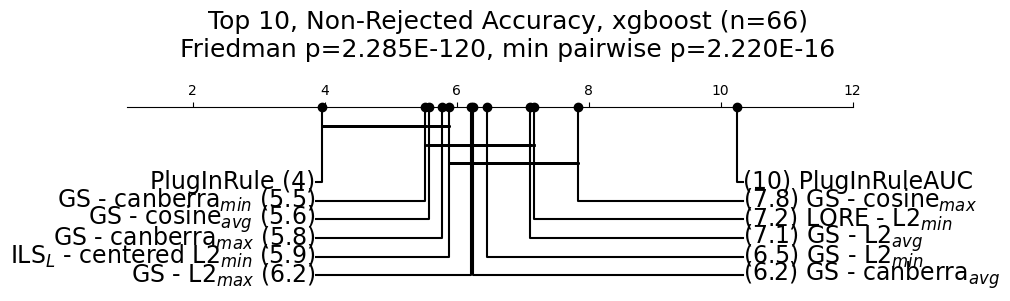

In [41]:
# 3. By model
for model in all_models:
    run_cd(f"Top {top_n}, {fancy_metric[metric]}, {fancy_model.get(model, model)}",
           all_datasets, [model],
           f"{cd_diagram_save_folder}/cd_{metric}_model_{model}.pdf")


# Line plots

In [42]:
import importlib.util
import yaml

spec = importlib.util.spec_from_file_location("sc", "4_selective_classifiers.py")
sc = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sc)

config = yaml.safe_load(open("config.yaml"))

# Load splits and compute original model accuracy for each dataset/model
all_original_scores_by_dataset = {}

for dataset in all_datasets:
    dp = sc.DataProcessor(config=config)
    splits = dp.load_splits(dataset)
    scores = {}
    for model_name in all_models:
        model_path = f"models/{dataset}/{model_name}.pkl"
        if os.path.exists(model_path):
            model = pickle.load(open(model_path, "rb"))
            scores[model_name] = sc.accuracy_score(splits["y_test"], model.predict(splits["X_test"]))
        else:
            print(f"  WARNING: {model_path} not found, falling back to PlugInRule at max coverage")
            df = dictionaries[dataset]["non_rejected_accuracy"][model_name]
            scores[model_name] = df.loc["PlugInRule", df.columns.max()]
    all_original_scores_by_dataset[dataset] = scores
    print(f"{dataset}: {scores}")


Loaded feature names from data/processed/toy_dataset/feature_names.csv
Loaded X_train from data/processed/toy_dataset/X_train.npz
Loaded y_train from data/processed/toy_dataset/y_train.npz
Loaded X_test from data/processed/toy_dataset/X_test.npz
Loaded y_test from data/processed/toy_dataset/y_test.npz
Loaded X_calibration from data/processed/toy_dataset/X_calibration.npz
Loaded y_calibration from data/processed/toy_dataset/y_calibration.npz
toy_dataset: {'mlp': 0.912, 'lip_mlp': 0.928, 'random_forest': 0.916, 'xgboost': 0.928}
Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz
german_c

In [43]:
n_per_dataset = 2  # best rejectors to pick per dataset (excluding baselines)


def score_methods(datasets, models_list):
    """Returns {method: mean_score} across given datasets and models."""
    scores = {}
    for d in datasets:
        for m in models_list:
            df = dictionaries[d][metric][m]
            for method in df.index:
                val = df.loc[method].mean()
                if not np.isnan(val):
                    scores.setdefault(method, []).append(val)
    return {k: np.mean(v) for k, v in scores.items()}


# For each dataset, pick the top n_per_dataset rejectors, then take the union
selected_set = []
for dataset in all_datasets:
    method_scores = score_methods([dataset], all_models)
    candidates = {m: s for m, s in method_scores.items()
                  if "_gamma" not in m and m not in always_include}
    top = sorted(candidates, key=candidates.get, reverse=True)[:n_per_dataset]
    print(f"{fancy_dataset.get(dataset, dataset)}: {[sc.fancy_names(m) for m in top]}")
    for m in top:
        if m not in selected_set:
            selected_set.append(m)

all_selected_methods = selected_set + list(always_include)

print(f"\nTotal: {len(all_selected_methods)} methods ({len(selected_set)} rejectors + {len(always_include)} baselines):")
for m in all_selected_methods:
    print(f"  {sc.fancy_names(m)}")


Two-Moons: ['GS - L2$_{max}$', 'GS - L2$_{avg}$']
German: ['GS - centered L2$_{min}$', 'GS - centered L2$_{avg}$']
Adult: ['ILS$_L$ - cosine$_{avg}$', 'ILS$_L$ - cosine$_{min}$']
Wisconsin: ['GS - cosine$_{max}$', 'GS - centered L2$_{avg}$']

Total: 9 methods (7 rejectors + 2 baselines):
  GS - L2$_{max}$
  GS - L2$_{avg}$
  GS - centered L2$_{min}$
  GS - centered L2$_{avg}$
  ILS$_L$ - cosine$_{avg}$
  ILS$_L$ - cosine$_{min}$
  GS - cosine$_{max}$
  PlugInRule
  PlugInRuleAUC


Two-Moons: ['GS - L2$_{max}$', 'GS - sqeuclidean$_{max}$']
German: ['GS - centered L2$_{min}$', 'GS - centered L2$_{avg}$']
Adult: ['ILS$_L$ - cosine$_{avg}$', 'ILS$_L$ - braycurtis$_{min}$']
Wisconsin: ['GS - cosine$_{max}$', 'GS - spearman$_{max}$']

Total: 10 methods (8 rejectors + 2 baselines):
  GS - L2$_{max}$
  GS - sqeuclidean$_{max}$
  GS - centered L2$_{min}$
  GS - centered L2$_{avg}$
  ILS$_L$ - cosine$_{avg}$
  ILS$_L$ - braycurtis$_{min}$
  GS - cosine$_{max}$
  GS - spearman$_{max}$
  PlugInRule
  PlugInRuleAUC

In [44]:
all_selected_methods = sorted(all_selected_methods)
all_selected_methods

['PlugInRule',
 'PlugInRuleAUC',
 'growingspheres_CFDistRejector_centered_l2_mean',
 'growingspheres_CFDistRejector_centered_l2_min',
 'growingspheres_CFDistRejector_cosine_max',
 'growingspheres_CFDistRejector_l2_max',
 'growingspheres_CFDistRejector_l2_mean',
 'ils<latent_CFDistRejector_cosine_mean',
 'ils<latent_CFDistRejector_cosine_min']

In [ ]:
# delta colors, wrt the family of the 


In [45]:
cf_generators = ["growingspheres", "ils<latent", "ils", "lore"]

In [46]:
plot_dir    = "SC-CE-paper/plots"


def build_plot_dataframes(dataset, methods, plot_metric="non_rejected_accuracy"):
    """Filter dictionaries to the requested methods, restoring baselines from raw if dropped."""
    dataframes = {}
    for model_name in all_models:
        df = dictionaries[dataset][plot_metric][model_name].copy()
        for b in always_include:
            if b not in df.index and b in raw_baselines[dataset][model_name][plot_metric].index:
                df = pd.concat([df, raw_baselines[dataset][model_name][plot_metric].loc[[b]]])
        df = df[~df.index.duplicated(keep='first')]
        # Align columns to the filtered dictionaries (raw_baselines may have extra columns)
        valid_cols = [c for c in df.columns if c in dictionaries[dataset][plot_metric][model_name].columns]
        df = df[valid_cols]
        keep = [m for m in methods if m in df.index]
        dataframes[model_name] = df.loc[keep]
    return dataframes

In [60]:
def simplified_plot_styling(method_name):
    """Simplified styling based on method name parsing."""
    style = {}
    method_name = method_name.lower()
    # Set defaults
    style['ls'] = '-'
    style['marker'] = ''
    style['color'] = 'blue'
    style['linewidth'] = 1.5
    style['markersize'] = 8
    
    # Check for baseline methods
    if 'plugin' in method_name:
        style['ls'] = '--'
        style['color'] = 'black'
        style['marker'] = 'o'
        if 'auc' in method_name:
            style['marker'] = '$A$'
            style['markersize'] = 10
        return style

    # Check for gamma distribution
    if 'gamma' in method_name:
        style['marker'] = '$\gamma$'
    else:
        style['markersize'] = 4

    # Color by CF generator
    if 'lore' in method_name:
        style['color'] = '#9467bd'  # Purple
    elif '$_l$' in method_name:
        style['color'] = '#ff7f0e'  # Orange
    elif 'dice' in method_name:
        style['color'] = '#2ca02c'  # Green
    elif 'ils' in method_name:
        style['color'] = '#d62728'  # Red
    elif 'gs' in method_name:
        style['color'] = '#1f77b4'  # Blue

    if 'min' in method_name:
        style['linewidth'] = 2.5
        style['ls'] = ':'
    if 'max' in method_name:
        style['linewidth'] = 2
    return style

In [61]:
def create_legend_file(top_policies_names, model_name,legend_fig_name):
    """Create a standalone legend file with metrics-based coloring."""
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.set_axis_off()  # Hide the axes
    print(top_policies_names)
    
    top_policies_names = list(set(top_policies_names))
    metric_methods = top_policies_names
    # place pluginrule and pluginruleauc at the beginning
    metric_methods = ["PlugInRule", "PlugInRuleAUC"] + [e for e in metric_methods if e not in ["PlugInRule", "PlugInRuleAUC"]] 
    ax.plot([], [], label=f"Original {model_name}", color='k', ls='--')
    for name in metric_methods:
        style = simplified_plot_styling(name)
        label = name
        ax.plot([], [], 
                    label=label,
                    marker=style['marker'],  # Standard marker
                    ls=style['ls'],
                    color=style['color'],
                    linewidth=style['linewidth'],
                    markersize=style['markersize'])
    
    # Create the legend with multiple columns
    legend = ax.legend(loc='center', ncol=4, frameon=False, fontsize=18, 
                      handlelength=2, handletextpad=0.5)
    # Save just the legend
    fig.savefig(f"{legend_fig_name}", bbox_inches='tight')


Plotting DATASET: toy_dataset
non_rejected_accuracy
non_rejected_accuracy
non_rejected_accuracy
non_rejected_accuracy


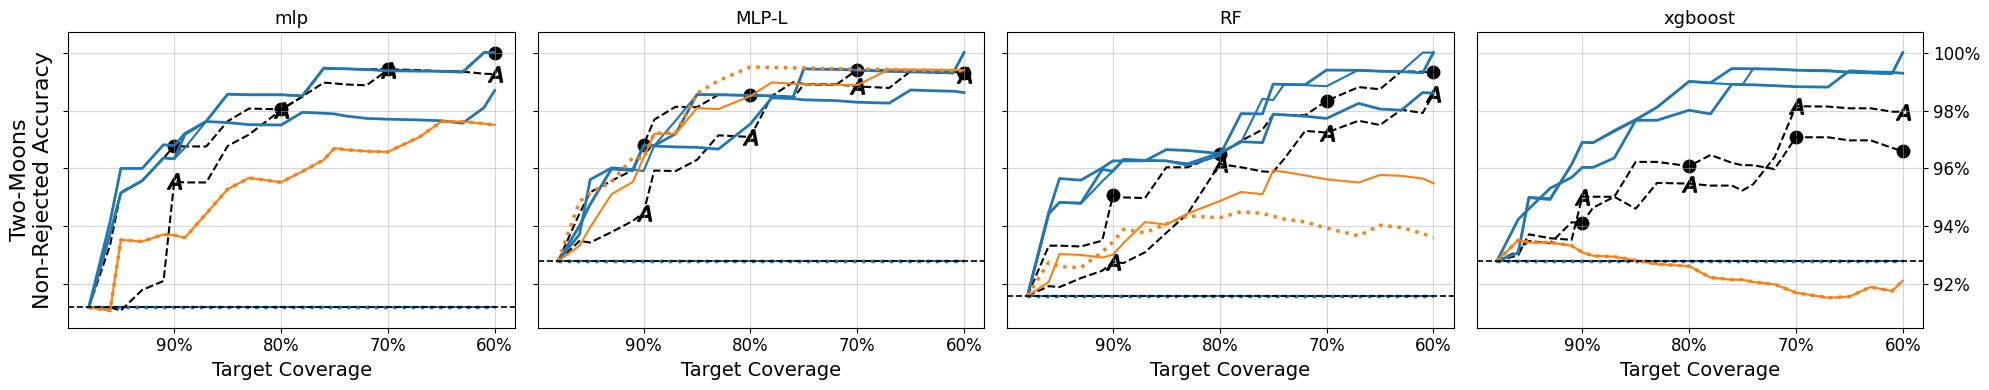

['PlugInRule', 'PlugInRuleAUC', 'GS - centered L2$_{avg}$', 'GS - centered L2$_{min}$', 'GS - cosine$_{max}$', 'GS - L2$_{max}$', 'GS - L2$_{avg}$', 'ILS$_L$ - cosine$_{avg}$', 'ILS$_L$ - cosine$_{min}$']

Plotting DATASET: german_credit
non_rejected_accuracy
non_rejected_accuracy
non_rejected_accuracy
non_rejected_accuracy


<Figure size 640x480 with 0 Axes>

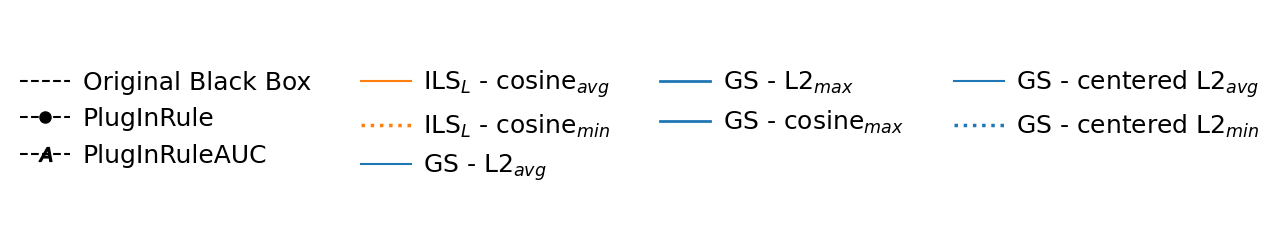

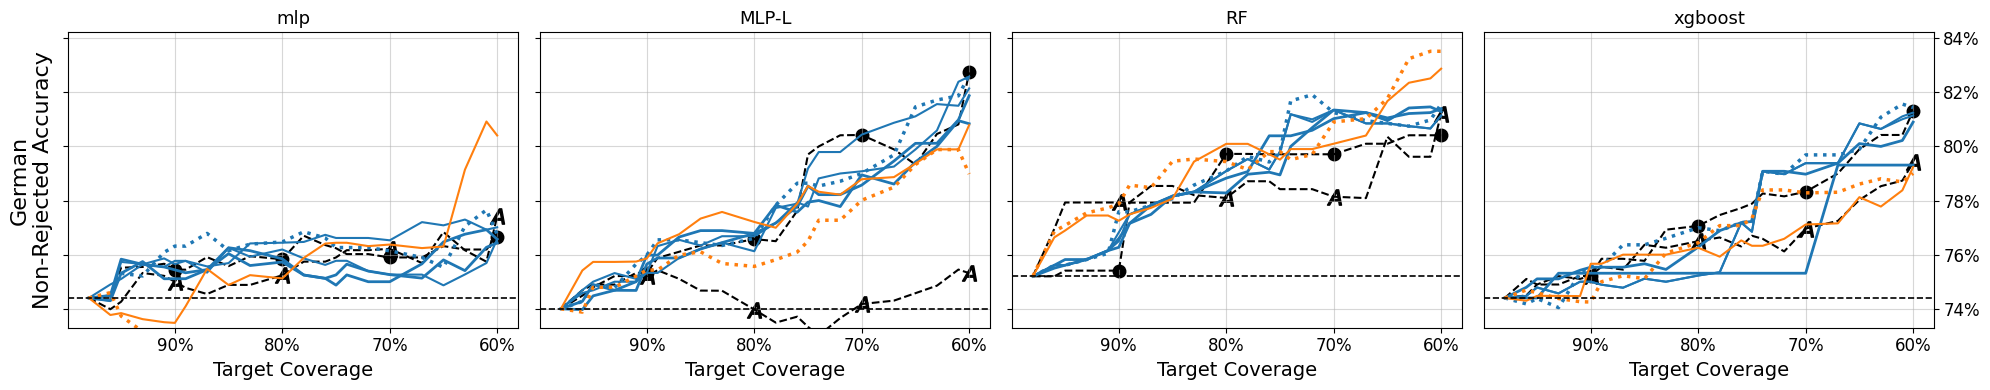


Plotting DATASET: adult48k
non_rejected_accuracy
non_rejected_accuracy
non_rejected_accuracy
non_rejected_accuracy


<Figure size 640x480 with 0 Axes>

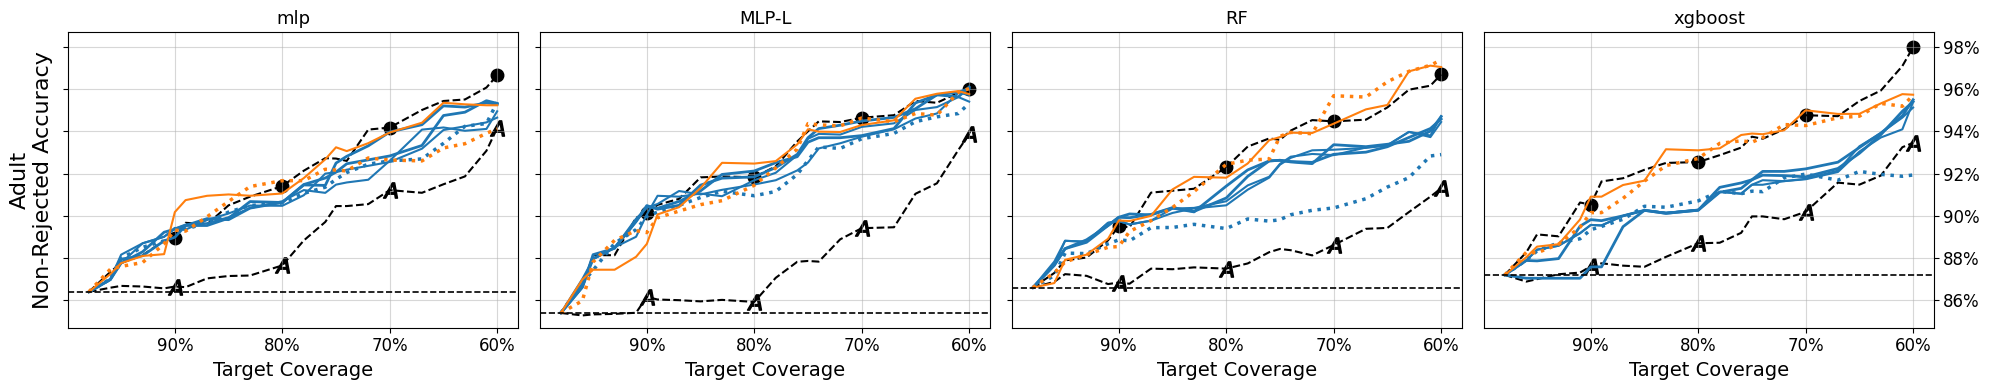


Plotting DATASET: breast_cancer
non_rejected_accuracy
non_rejected_accuracy
non_rejected_accuracy
non_rejected_accuracy


<Figure size 640x480 with 0 Axes>

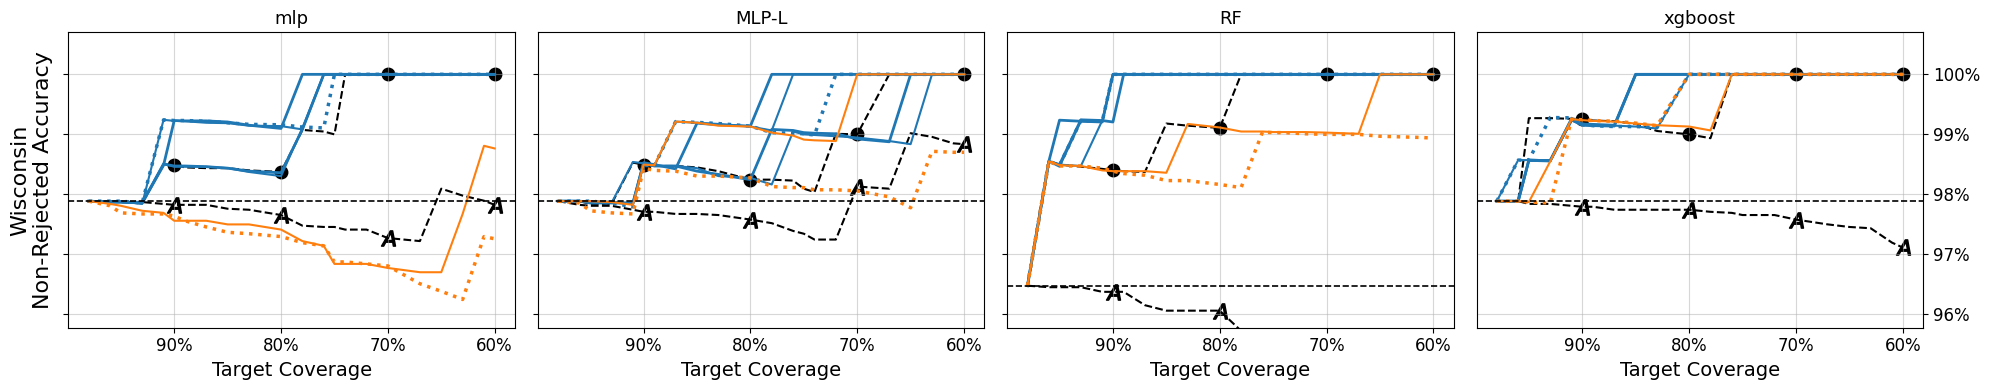


Plotting DATASET: toy_dataset


<Figure size 640x480 with 0 Axes>

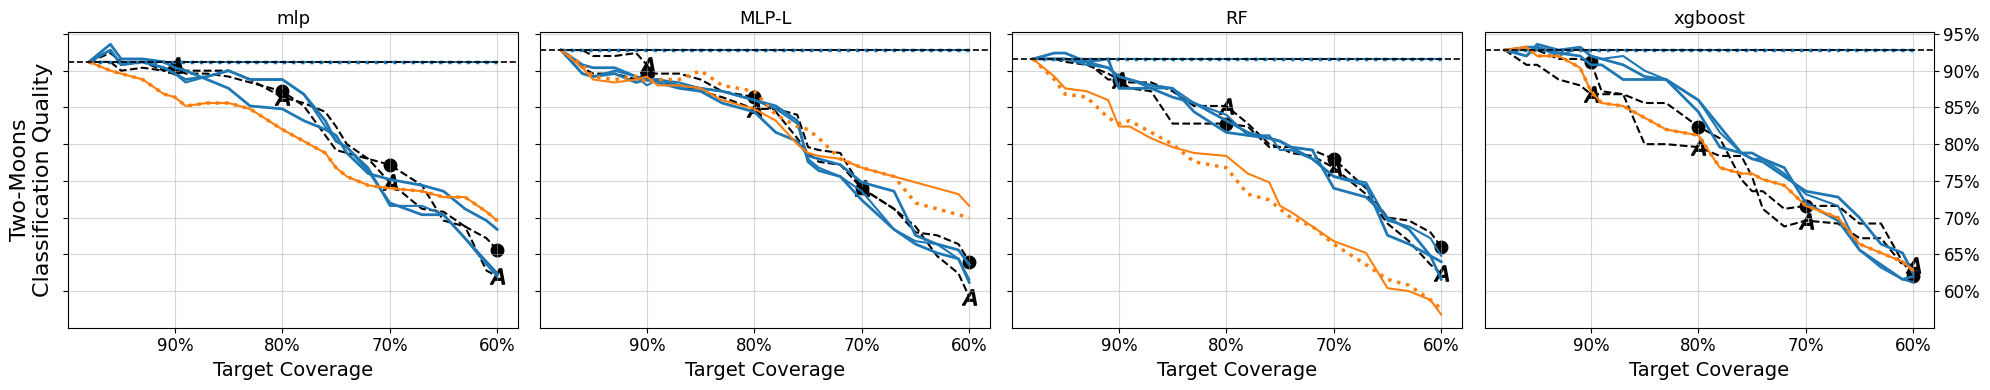

['PlugInRule', 'PlugInRuleAUC', 'GS - centered L2$_{avg}$', 'GS - centered L2$_{min}$', 'GS - cosine$_{max}$', 'GS - L2$_{max}$', 'GS - L2$_{avg}$', 'ILS$_L$ - cosine$_{avg}$', 'ILS$_L$ - cosine$_{min}$']

Plotting DATASET: german_credit


<Figure size 640x480 with 0 Axes>

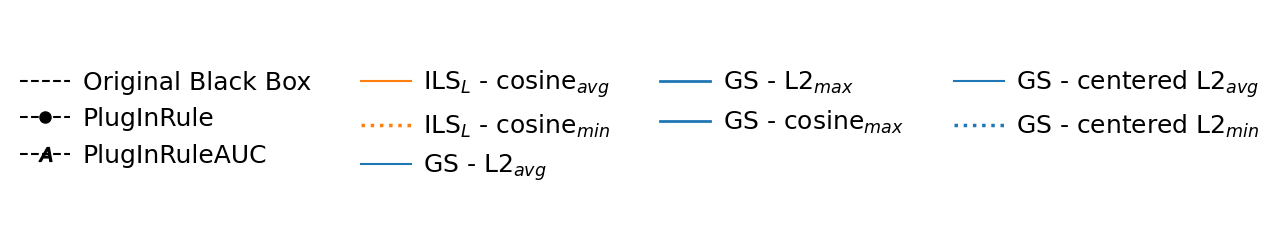

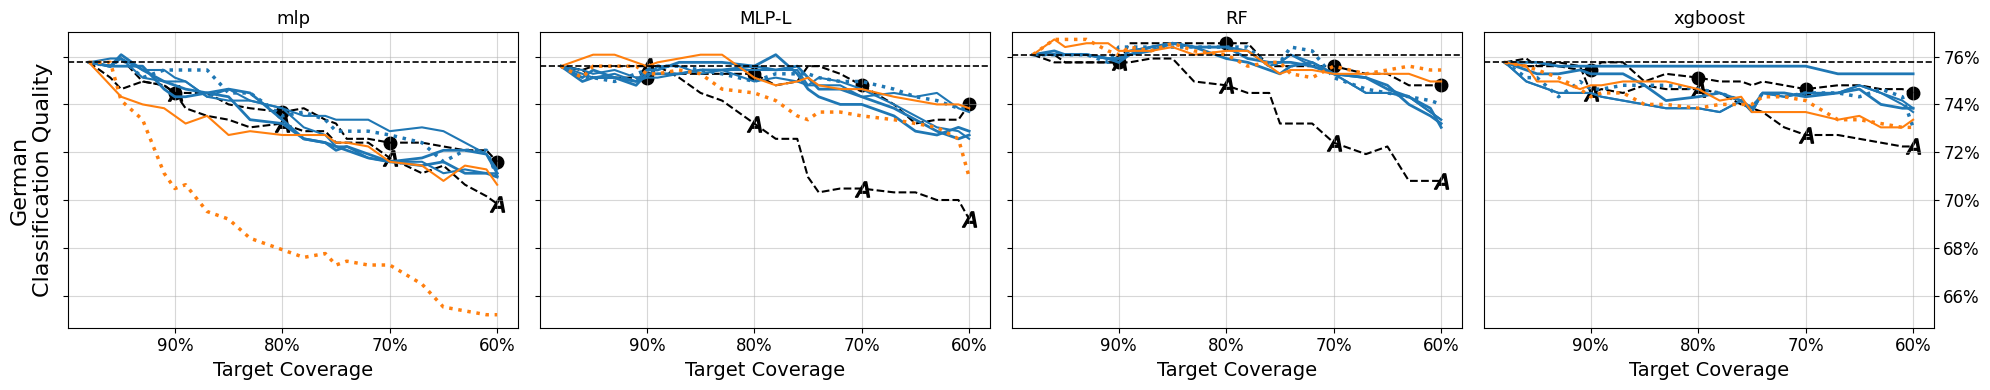


Plotting DATASET: adult48k


<Figure size 640x480 with 0 Axes>

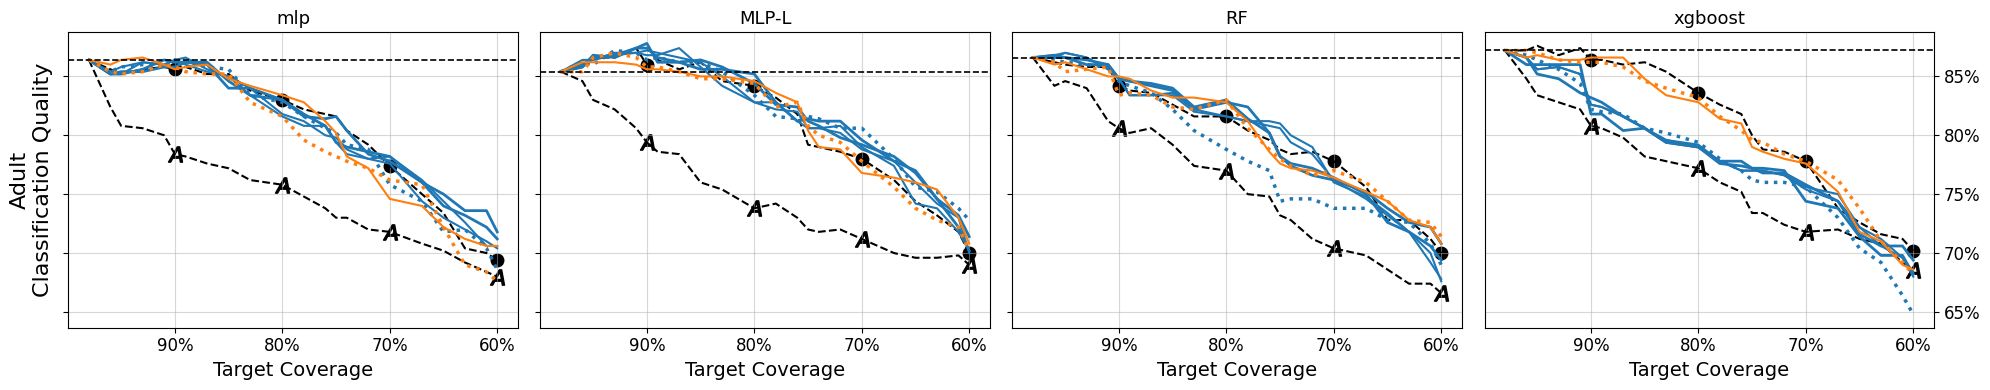


Plotting DATASET: breast_cancer


<Figure size 640x480 with 0 Axes>

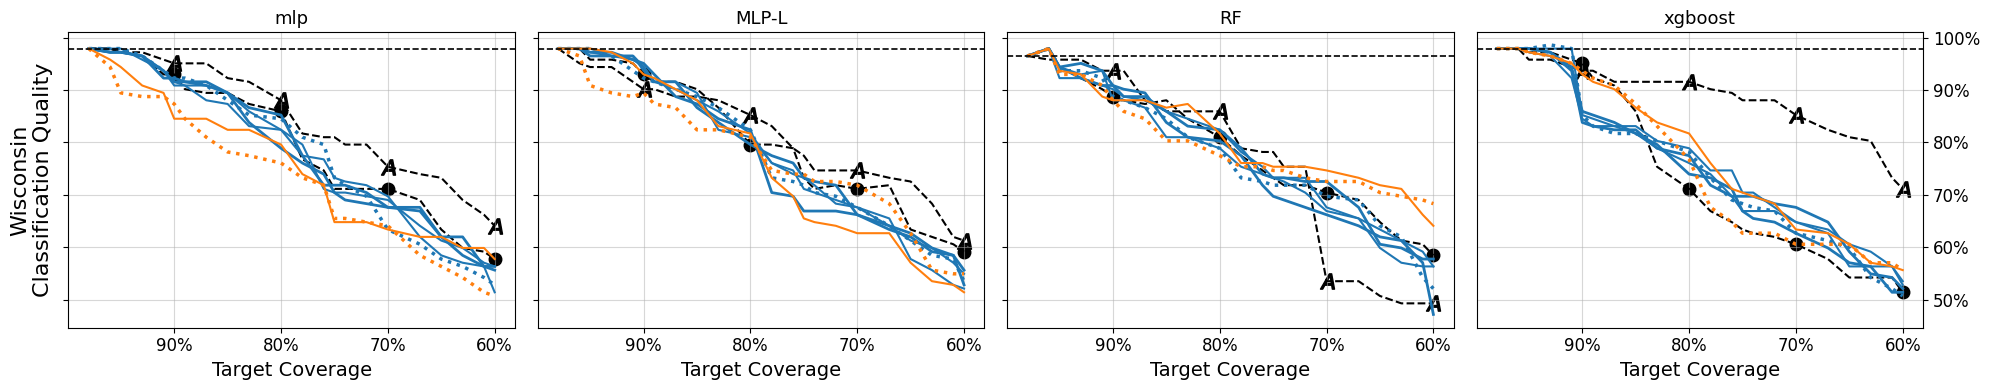

<Figure size 640x480 with 0 Axes>

In [ ]:
def plot_by_model(dataset, dataframes,plot_metric, save_path=None, show=True,
                  ):
    """One subplot per model, all selected methods plotted.
    Uses raw method names for styling so CF generator colors are correct."""
    n_models = len(all_models)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
    axes = np.array(axes).flatten()

    col_ticks = np.array(list(dataframes[all_models[0]].columns))
    col_ticks = col_ticks[((col_ticks * 100) % 10 == 0)]
    vminimum = min(all_original_scores_by_dataset[dataset].values())
    vmaximum = max(df.loc[method].max() for df in dataframes.values() for method in df.index)
    vminimum -= 0.007
    vmaximum += 0.007
    if plot_metric != "non_rejected_accuracy":
        vminimum = 1
        vmaximum = 0
    for indx, model_name in enumerate(all_models):
        ax  = axes[indx]
        df  = dataframes[model_name]

        for m in df.index:
            style = simplified_plot_styling(fancy_names(m))        # raw name, correct colors
            label = sc.fancy_names(m)
            # print the m, the label and the std
            # print(m, label, df.loc[m].std())
            # plot with the marker fewer points, only at %10 == 0 coverage levels
            ax.plot(df.columns, df.loc[m], label=label,
                    ls=style['ls'], color=style['color'],
                    linewidth=style['linewidth'],
                    # marker=style['marker'],
                    # markersize=style['markersize']
                    )
            selected_cols = [col for col in df.columns if col in col_ticks]
            ax.scatter(selected_cols, 
                       df.loc[m].loc[selected_cols], 
                       color=style['color'], 
                       s=(style['markersize']+1)**2,
                       marker=style['marker'],
                       )

        ax.axhline(all_original_scores_by_dataset[dataset][model_name],
                   color='k', ls='--', linewidth=1.2)

        ax.set_xticks(col_ticks)
        ax.set_xticklabels([f"{e*100:.0f}%" for e in col_ticks], rotation=0, fontsize=12)
        xlims = ax.get_xlim()
        ax.set_xlim(xlims[1], xlims[0])
        ax.set_xlabel("Target Coverage", fontsize=14)
        
        ax.set_title(fancy_model[model_name], fontsize=13)
        
        if plot_metric == "non_rejected_accuracy":
            print(plot_metric)
            ax.set_ylim(vminimum, vmaximum)
        else:
            vmaximum = max(vmaximum, ax.get_ylim()[1])
            vminimum = min(vminimum, ax.get_ylim()[0])
        ax.grid(True, alpha=0.5)

        if indx == 0:
            ax.set_ylabel("\n".join([
                fancy_dataset[dataset],
                fancy_metric[plot_metric]
                ]), fontsize=16)

        if indx == n_models - 1:
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")
            ax.set_yticklabels([f"{e*100:.0f}%" for e in ax.get_yticks()], fontsize=12)
        else:
            ax.set_yticklabels([""] * len(ax.get_yticks()))
    for ax in axes:
        
        ax.set_ylim(vminimum, vmaximum)
    # plt.suptitle(f"{fancy_dataset.get(dataset, dataset)}, {fancy_metric[plot_metric]}",
    #              fontsize=16, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    if show:
        plt.show()
    plotted_methods = [fancy_names(m) for m in all_selected_methods]
    plt.close(fig)
    plt.clf()
    if dataset == all_datasets[0]:  # Only create legend for the first dataset (since method set is the same)
        create_legend_file(plotted_methods, "Black Box", save_path.replace(".pdf", "_legend.pdf"))

for m2plot in [
    "non_rejected_accuracy",
     "classification_quality_dict"
     ]:
    for dataset in all_datasets:
        dataframes = build_plot_dataframes(dataset, all_selected_methods, plot_metric=m2plot)
        print(f"\nPlotting DATASET: {dataset}")
        plot_by_model(dataset, dataframes, plot_metric=m2plot,
                  save_path=f"{plot_dir}/by_model_{dataset}_{m2plot}.pdf",
                  show=True)


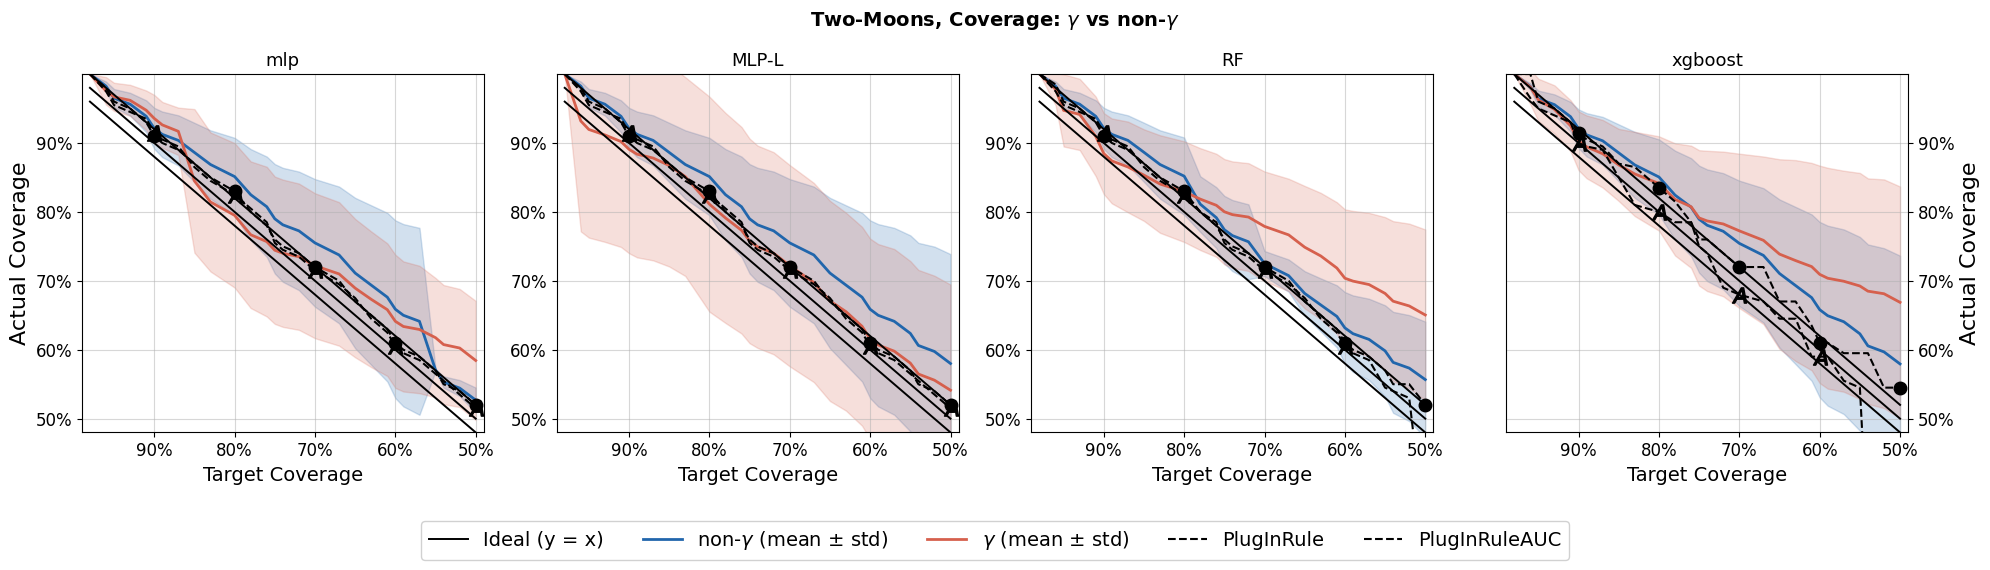

<Figure size 640x480 with 0 Axes>

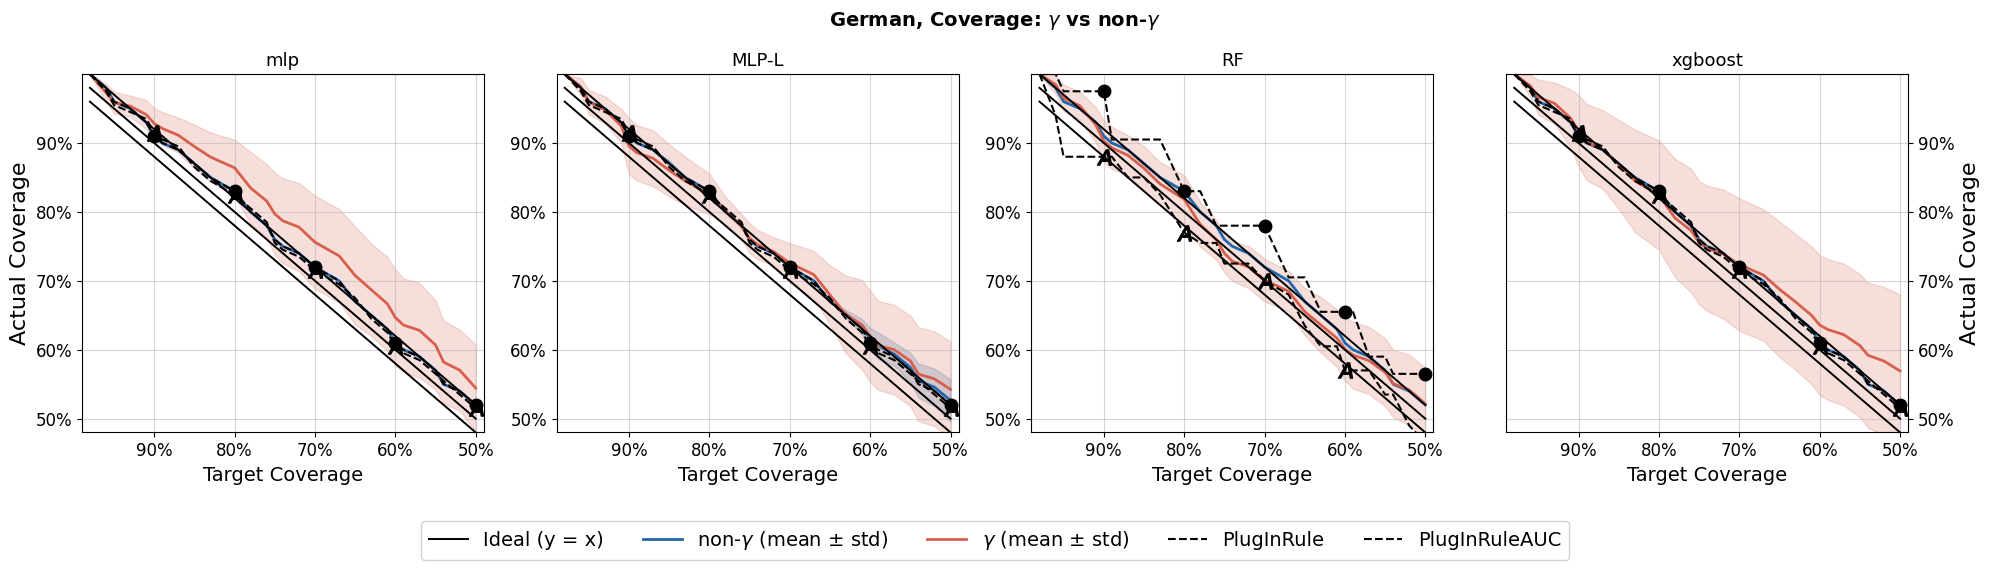

<Figure size 640x480 with 0 Axes>

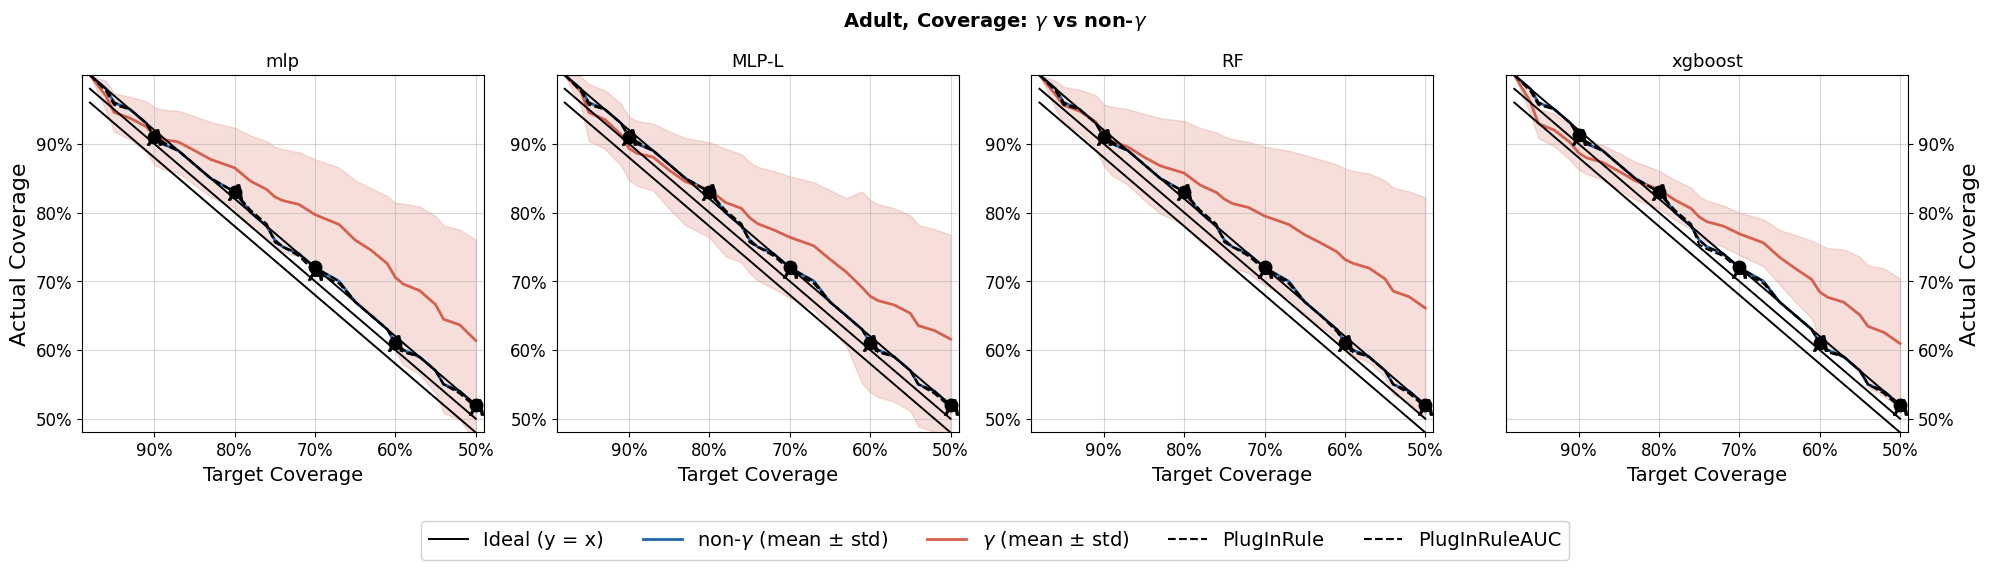

<Figure size 640x480 with 0 Axes>

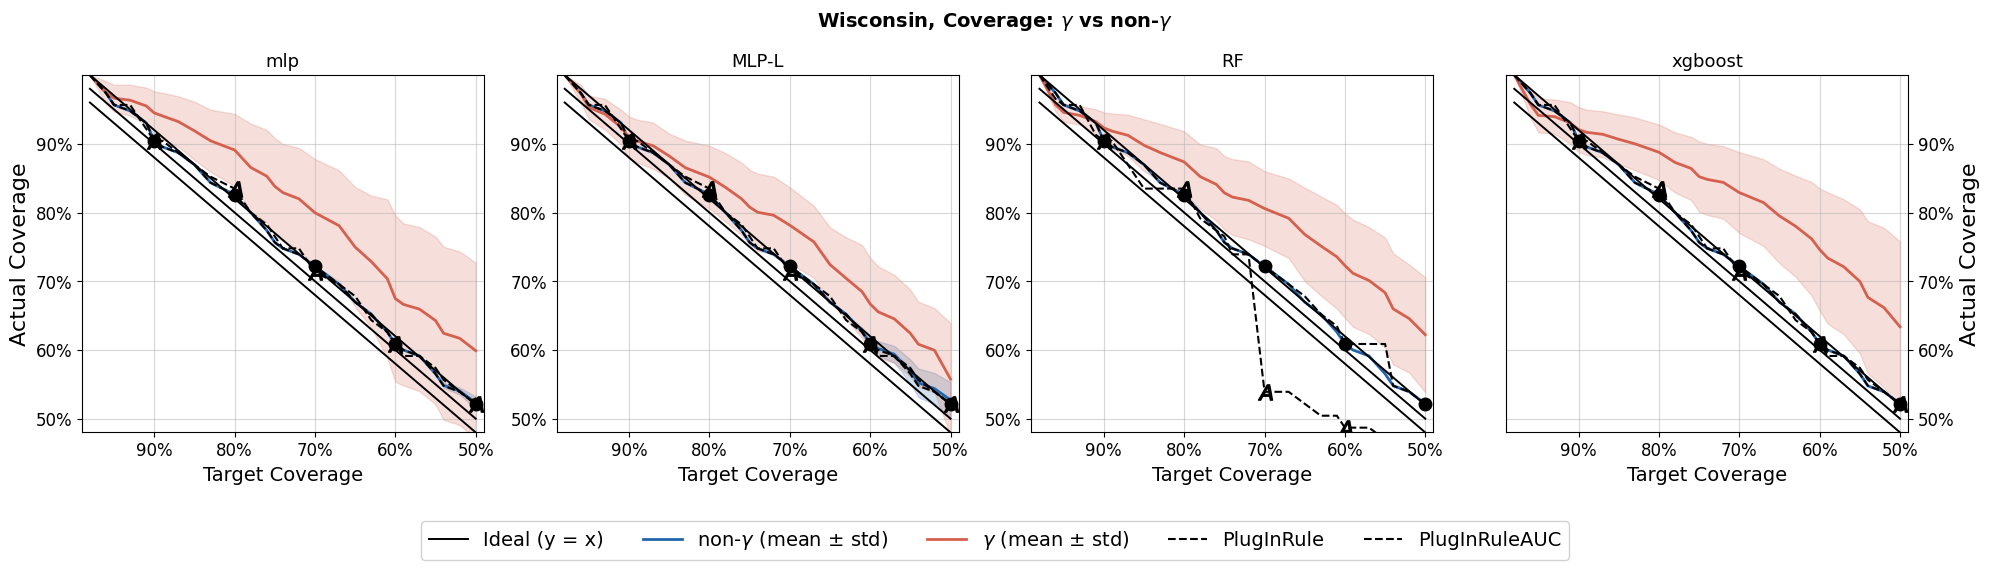

<Figure size 640x480 with 0 Axes>

In [64]:

def plot_coverage_tracking(dataset, save_path=None, show=True):
    """
    For each model: plot actual vs target coverage.
    - gamma methods:     mean ± std (red-orange shaded area)
    - non-gamma methods: mean ± std (blue shaded area)
    - always_include:    individual lines using their standard style
    - ideal y=x diagonal
    Shared legend centered at the bottom of the figure.
    """
    n_models = len(all_models)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    axes = np.array(axes).flatten()

    color_nongamma = "#2166ac"   # blue
    color_gamma    = "#d6604d"   # red-orange

    legend_handles = []
    legend_labels  = []

    for indx, model_name in enumerate(all_models):
        ax = axes[indx]
        cov_df = dictionaries[dataset]["calibration_coverage"][model_name]

        gamma_methods    = [m for m in cov_df.index if "_gamma" in m and m not in always_include     and "ils" in m.lower()]
        nongamma_methods = [m for m in cov_df.index if "_gamma" not in m and m not in always_include and "ils" in m.lower()]

        target_levels = cov_df.columns.values

        # --- ideal diagonal ---
        h, = ax.plot(target_levels, target_levels,
                     color="black", ls="-", linewidth=1.4, zorder=5)
        h, = ax.plot(target_levels, target_levels-0.02,
                     color="black", ls="-", linewidth=1.4, zorder=5)
        h, = ax.plot(target_levels, target_levels+0.02,
                     color="black", ls="-", linewidth=1.4, zorder=5)
        if indx == 0:
            legend_handles.append(h)
            legend_labels.append("Ideal (y = x)")

        # --- non-gamma group ---
        if nongamma_methods:
            arr  = cov_df.loc[nongamma_methods].values
            mean = np.nanmean(arr, axis=0)
            std  = np.nanstd(arr, axis=0)
            h, = ax.plot(target_levels, mean,
                         color=color_nongamma, lw=2)
            ax.fill_between(target_levels, mean - std, mean + std,
                            color=color_nongamma, alpha=0.2)
            if indx == 0:
                legend_handles.append(h)
                legend_labels.append("non-$\\gamma$ (mean ± std)")

        # --- gamma group ---
        if gamma_methods:
            arr  = cov_df.loc[gamma_methods].values
            mean = np.nanmean(arr, axis=0)
            std  = np.nanstd(arr, axis=0)
            h, = ax.plot(target_levels, mean,
                         color=color_gamma, lw=2)
            ax.fill_between(target_levels, mean - std, mean + std,
                            color=color_gamma, alpha=0.2)
            if indx == 0:
                legend_handles.append(h)
                legend_labels.append("$\\gamma$ (mean ± std)")

        # --- always_include baselines (individual lines) ---
        for m in always_include:
            if m not in cov_df.index:
                continue
            style = simplified_plot_styling(m)
            label = fancy_names(m)
            h, = ax.plot(target_levels, cov_df.loc[m].values,
                         color=style['color'], ls=style['ls'],
                         linewidth=style['linewidth'])
            ax.scatter(
                target_levels[((target_levels * 100) % 10 == 0)],
                cov_df.loc[m].loc[target_levels[((target_levels * 100) % 10 == 0)]].values,
                color=style['color'], marker=style['marker'],
                s=(style['markersize'] + 1) ** 2, zorder=6
            )
            if indx == 0:
                legend_handles.append(h)
                legend_labels.append(label)

        # --- axes formatting ---
        col_ticks = target_levels[((target_levels * 100) % 10 == 0)]
        ax.set_xticks(col_ticks)
        ax.set_xticklabels([f"{e*100:.0f}%" for e in col_ticks], rotation=0, fontsize=12)
        ax.set_yticks(col_ticks)
        ax.set_yticklabels([f"{e*100:.0f}%" for e in col_ticks], fontsize=12)

        ax.set_xlim(max(target_levels) + 0.01, min(target_levels) - 0.01)
        ax.set_ylim(min(target_levels) - 0.02, max(target_levels) + 0.02)

        ax.set_xlabel("Target Coverage", fontsize=14)
        ax.set_title(fancy_model[model_name], fontsize=13)
        ax.grid(True, alpha=0.5)

        if indx == 0:
            ax.set_ylabel("Actual Coverage", fontsize=16)

        if indx == n_models - 1:
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")
            ax.set_ylabel("Actual Coverage", fontsize=16)

    plt.suptitle(
        f"{fancy_dataset[dataset]}, Coverage: $\\gamma$ vs non-$\\gamma$",
        fontsize=14, fontweight="bold"
    )

    # shared legend centered at the bottom
    fig.legend(
        legend_handles, legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=len(legend_handles),
        fontsize=14,
        frameon=True,
        framealpha=0.9,
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    if show:
        plt.show()
    plt.close(fig)
    plt.clf()


# --- run for all datasets ---
for dataset in all_datasets:
    plot_coverage_tracking(
        dataset,
        save_path=False,#f"Figures/coverage_tracking_{dataset}.pdf",
        show=True,
    )


In [29]:
sc.name_dataset_command

{'German Credit': '\\german',
 'Adult': '\\adult',
 'Two Moons': '\\twomoons',
 'Breast Cancer': '\\breastcancer',
 'toy_dataset': '\\twomoons',
 'german_credit': '\\german',
 'adult48k': '\\adult',
 'breast_cancer': '\\breastcancer'}

In [ ]:
def generate_tables_by_model(dataset, plot_metric, save_path_dir="SC-CE-paper/Tables/tables", top_k=7):
    """Generate LaTeX tables: top-k methods ranked per model by fake AUC."""
    os.makedirs(save_path_dir, exist_ok=True)

    latex_tables = {}
    n_models = len(all_models)

    for indx, model_name in enumerate(all_models):
        # Use full unfiltered data for ranking
        df = dictionaries[dataset][plot_metric][model_name].copy()
        for b in always_include:
            if b not in df.index and b in raw_baselines[dataset][model_name][plot_metric].index:
                df = pd.concat([df, raw_baselines[dataset][model_name][plot_metric].loc[[b]]])
        df = df[~df.index.duplicated(keep='first')]
        # Drop columns reintroduced by raw_baselines that were filtered out (e.g. coverage < 0.6)
        valid_cols = dictionaries[dataset][plot_metric][model_name].columns
        df = df[[c for c in df.columns if c in valid_cols]]

        # Filter columns to multiples of 5%, use round to avoid floating point issues
        col_filter = np.array(list(df.columns))
        col_filter = col_filter[(np.round(col_filter * 100).astype(int) % 5) == 0]
        df = df.loc[:, col_filter.tolist()]

        index_list = list(df.index)

        # Rank by fake AUC, excluding baselines and _gamma variants
        rankable = [i for i, m in enumerate(index_list)
                    if m not in always_include and '_gamma' not in m]
        scores = df.values.sum(axis=1)
        ranked = sorted(rankable, key=lambda i: scores[i], reverse=True)
        top_policies = ranked[:top_k]

        # Always include baselines at the front
        baseline_indices = [index_list.index(b) for b in always_include if b in index_list]
        top_policies = baseline_indices + [e for e in top_policies if e not in baseline_indices]

        top_policies_names = [sc.fancy_names(index_list[i], command=True) for i in top_policies]

        latex_tables[model_name] = sc.generate_latex_table(
            ldf=df,
            black_box_score=all_original_scores_by_dataset[dataset][model_name],
            black_box_name=model_name,
            top_policies=top_policies,
            top_policies_names=top_policies_names,
            target_coverages=col_filter.tolist(),
            dataset_name=dataset,
            sorted_rows=[index_list[i] for i in top_policies],
            print_heaedr=(indx == 0),
            print_footer=(indx == n_models - 1),
        )

    table_path = os.path.join(save_path_dir, f"latex_table_{plot_metric}_{sc.fancy_dataset_names[dataset].replace(' ', '_')}.tex")
    with open(table_path, "w") as f:
        for model_name in all_models:
            f.write(latex_tables[model_name].replace("Selective Classifiers for the dataset", f"Selective Classifiers in {fancy_metric[plot_metric]} for the dataset"))
    print(f"Saved: {table_path}")
    return latex_tables

for m2plot in [
    "non_rejected_accuracy",
     "classification_quality_dict"
     ]:
    for dataset in all_datasets:
        generate_tables_by_model(dataset, m2plot)

growingspheres_CFDistRejector_MAE_mean MAE \growingspheres
growingspheres_CFDistRejector_MAE_min MAE \growingspheres
growingspheres_CFDistRejector_MAE_max MAE \growingspheres
growingspheres_CFDistRejector_L2_min L2 \growingspheres
growingspheres_CFDistRejector_sqeuclidean_min sqeuclidean \growingspheres
growingspheres_CFDistRejector_inf_max inf \growingspheres
growingspheres_CFDistRejector_L2_max L2 \growingspheres
growingspheres_CFDistRejector_inf_mean inf \growingspheres
growingspheres_CFDistRejector_L2_max L2 \growingspheres
growingspheres_CFDistRejector_inf_max inf \growingspheres
growingspheres_CFDistRejector_L2_max L2 \growingspheres
growingspheres_CFDistRejector_sqeuclidean_max sqeuclidean \growingspheres
growingspheres_CFDistRejector_MAE_max MAE \growingspheres
growingspheres_CFDistRejector_MAE_min MAE \growingspheres
growingspheres_CFDistRejector_L2_mean L2 \growingspheres
growingspheres_CFDistRejector_MAE_mean MAE \growingspheres
Saved: SC-CE-paper/Tables/tables/latex_table_n

## REAL COVERAGE (End of the file)

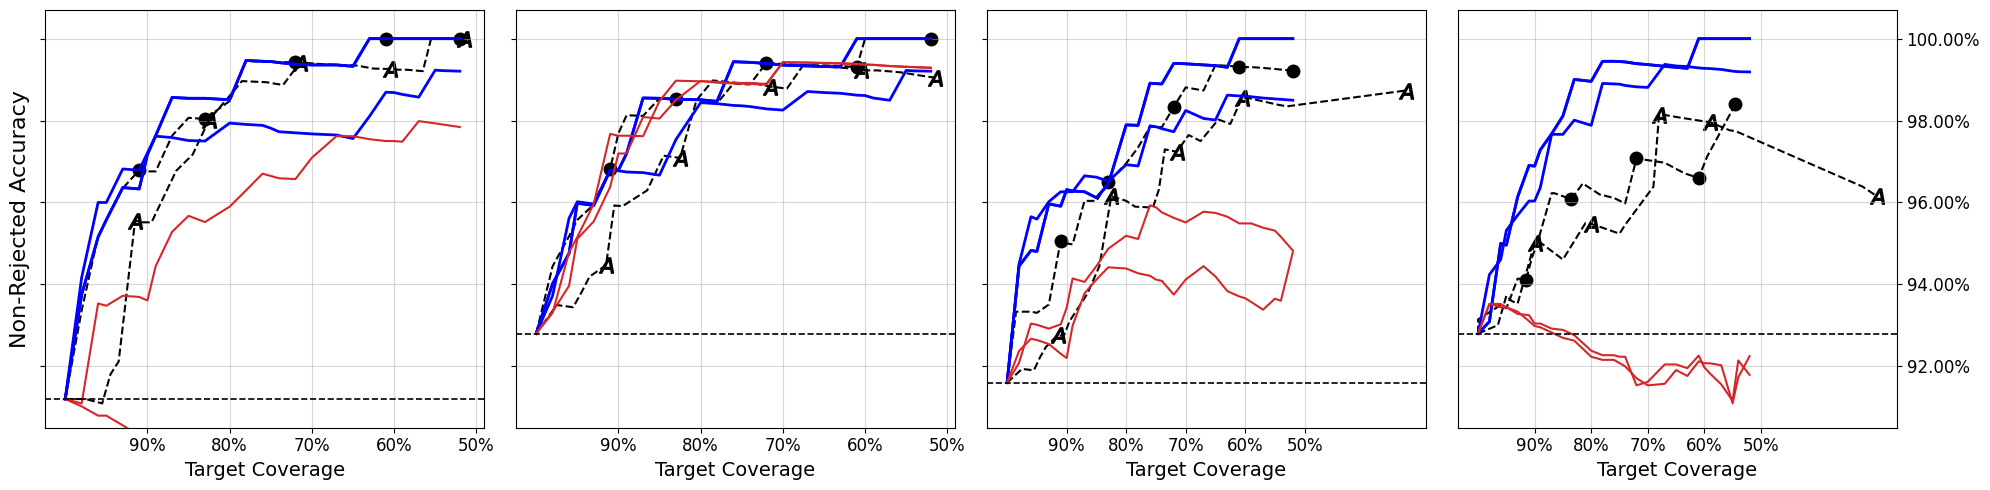

['PlugInRule', 'PlugInRuleAUC', 'GS - centered L2$_{avg}$', 'GS - centered L2$_{min}$', 'GS - cosine$_{max}$', 'GS - l2$_{max}$', 'GS - spearman$_{max}$', 'GS - sqeuclidean$_{max}$', 'ILS$_L$ - braycurtis$_{avg}$', 'ILS$_L$ - cosine$_{avg}$']


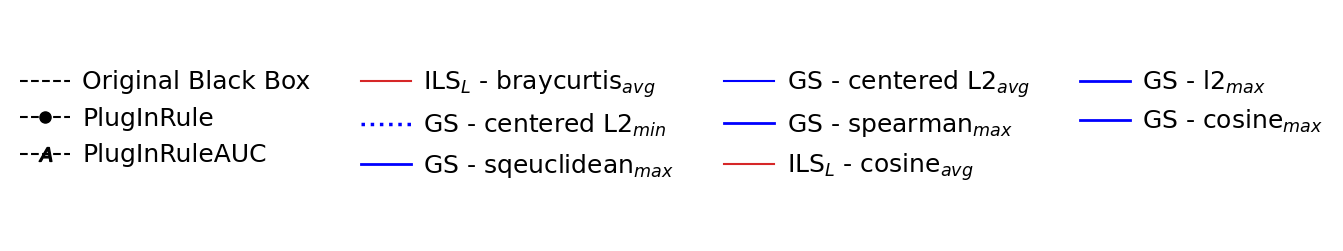

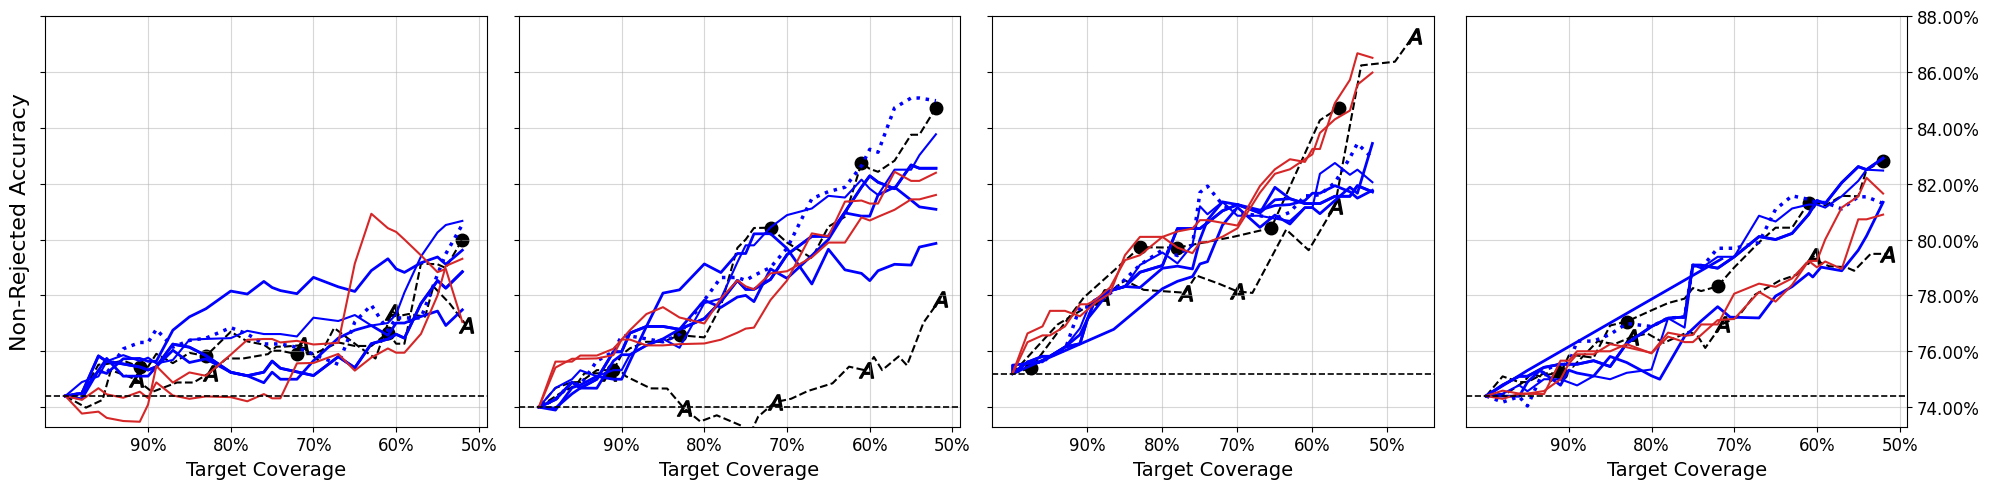

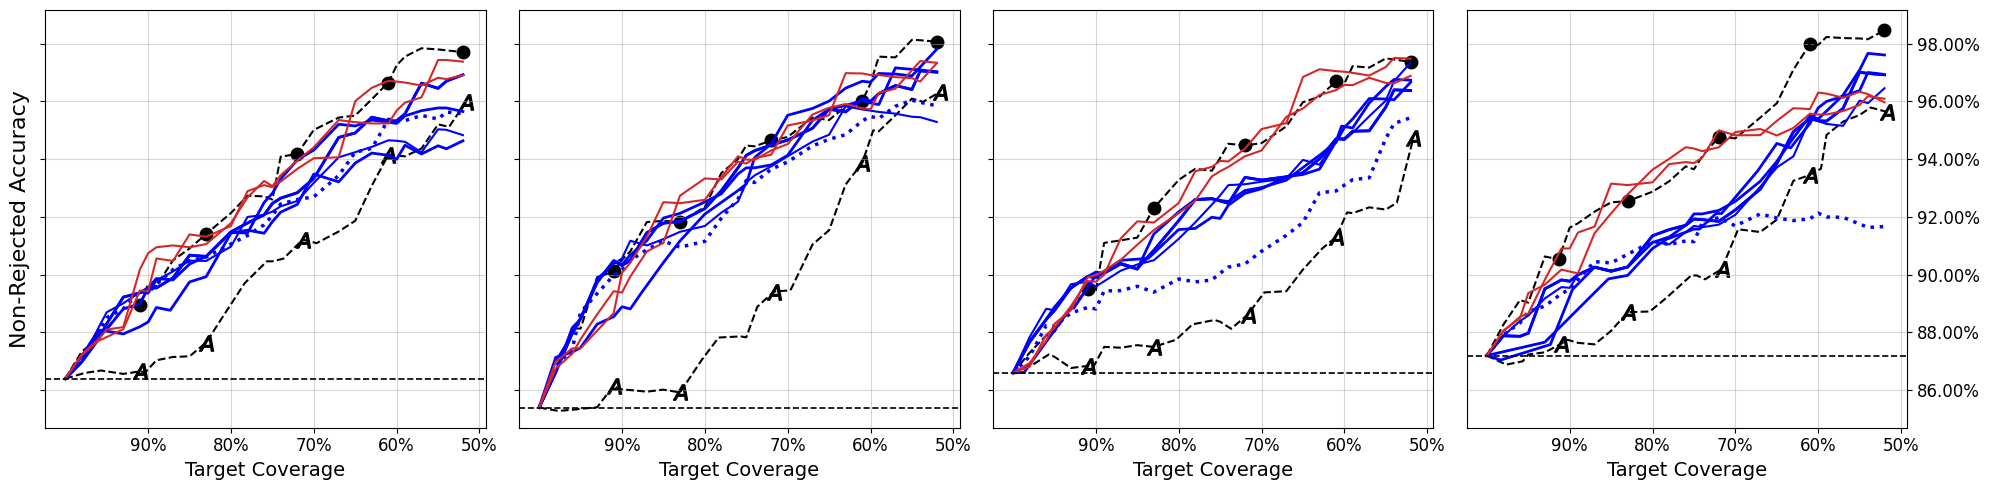

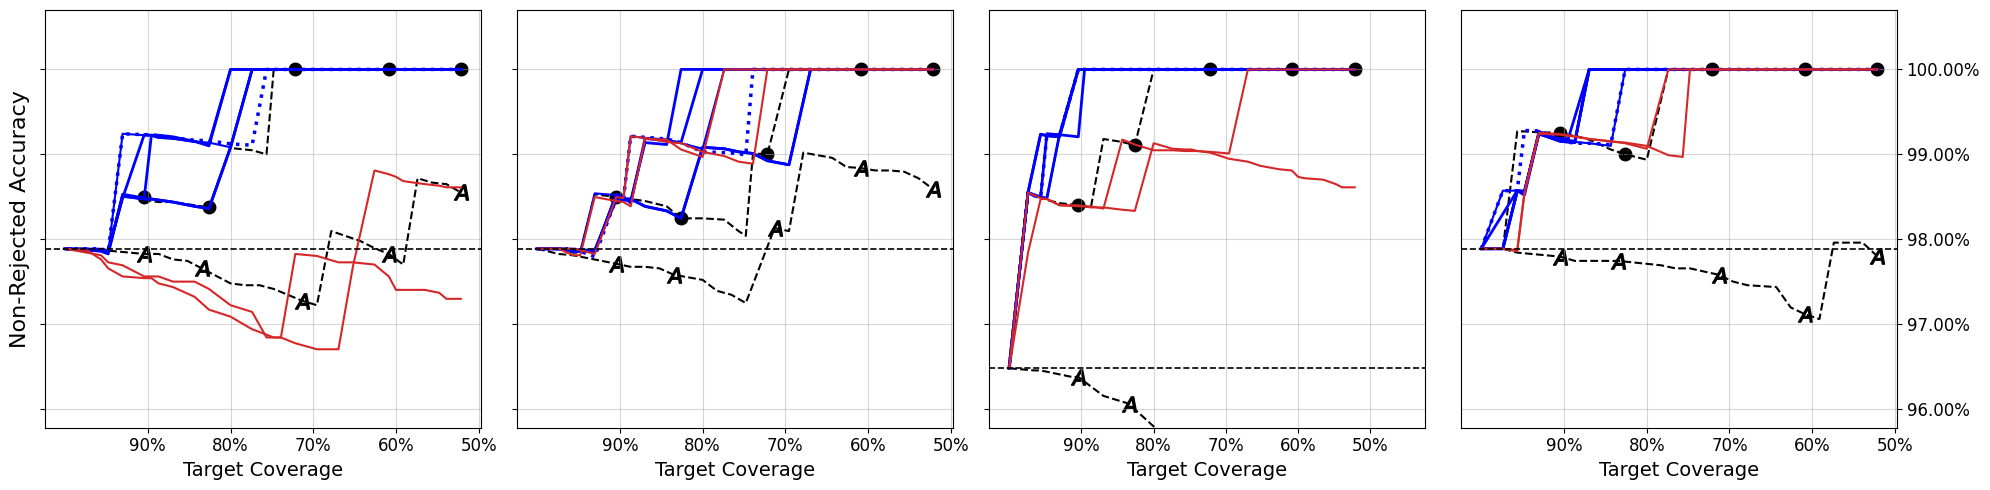

In [ ]:
def plot_by_model_real_coverage(dataset, dataframes, save_path=None, show=True):
    """One subplot per model, all selected methods plotted.
    Uses raw method names for styling so CF generator colors are correct."""
    n_models = len(all_models)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    axes = np.array(axes).flatten()

    col_ticks = np.array(list(dataframes[all_models[0]].columns))
    col_ticks = col_ticks[((col_ticks * 100) % 10 == 0)]
    vminimum = min(all_original_scores_by_dataset[dataset].values())
    vmaximum = max(df.loc[method].max() for df in dataframes.values() for method in df.index)
    vminimum -= 0.007
    vmaximum += 0.007
    for indx, model_name in enumerate(all_models):
        ax  = axes[indx]
        df  = dataframes[model_name]

        for m in df.index:
            style = simplified_plot_styling(fancy_names(m))        # raw name, correct colors
            label = sc.fancy_names(m)
            # print the m, the label and the std
            calibration_df = dictionaries[dataset]["calibration_coverage"][model_name]
            
            # print(m, label, df.loc[m].std())

            ax.plot(calibration_df.loc[m], df.loc[m], label=label,
                    ls=style['ls'], color=style['color'],
                    linewidth=style['linewidth'],
                    # marker=style['marker'],
                    # markersize=style['markersize']
                    )
            # plot with the marker fewer points, only at %10 == 0 coverage levels
            selected_cols = [col for col in df.columns if col in col_ticks]
            
            ax.scatter(calibration_df.loc[m][selected_cols], 
                       df.loc[m].loc[selected_cols], 
                       color=style['color'], 
                       s=(style['markersize']+1)**2,
                       marker=style['marker'],
                       )

        ax.axhline(all_original_scores_by_dataset[dataset][model_name],
                   color='k', ls='--', linewidth=1.2)

        ax.set_xticks(col_ticks)
        ax.set_xticklabels([f"{e*100:.0f}%" for e in col_ticks], rotation=0, fontsize=12)
        xlims = ax.get_xlim()
        ax.set_xlim(xlims[1], xlims[0])
        ax.set_xlabel("Target Coverage", fontsize=14)
        ax.set_ylim(vminimum, vmaximum)
        ax.grid(True, alpha=0.5)

        if indx == 0:
            ax.set_ylabel(fancy_metric[plot_metric], fontsize=16)

        if indx == n_models - 1:
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")
            ax.set_yticklabels([f"{e*100:.2f}%" for e in ax.get_yticks()], fontsize=12)
        else:
            ax.set_yticklabels([""] * len(ax.get_yticks()))

    # plt.suptitle(f"{fancy_dataset.get(dataset, dataset)}, {fancy_metric[plot_metric]}",
    #              fontsize=16, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    if show:
        plt.show()
    plotted_methods = [fancy_names(m) for m in all_selected_methods]
    plt.close(fig)
    if dataset == all_datasets[0]:  # Only create legend for the first dataset (since method set is the same)
        create_legend_file(plotted_methods, "Black Box", save_path.replace(".pdf", "_legend.pdf"))


for dataset in all_datasets:
    dataframes = build_plot_dataframes(dataset, all_selected_methods)
    plot_by_model_real_coverage(dataset, dataframes,
                  save_path=f"{plot_dir}/by_model_{dataset}_{plot_metric}.pdf",
                  show=True)
